### Extraction of Data for plotting of MP2-cylinder-paper data.
- create index table which contains all simulations with its parameters, stats and the status if drag and lift timeseries are available
- extract chosen data timeseries for drag and lift coefficient and save them in a new folder with all relevant parameters in their name
- FUTURE: do statistics on data, pre-analyze (plot), incorporate data in plots of cylinder-paper

#### IMPORTS

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import detrend
from scipy.stats import sem
import re
import os
import shutil
from pathlib import Path
import time
import matplotlib.pyplot as plt

### INITIALIZATION of FUNCTIONS and FUNCTIONALITY:

In [2]:
# ==========================================
# 1. HELFER-FUNKTIONEN
# ==========================================

def get_time_range(file_path):
    """Liest Start und Ende der Zeitreihe aus (überspringt Header)."""
    try:
        with open(file_path, 'rb') as f:
            f.readline()  # Header überspringen
            first_line = f.readline().decode().split()
            if not first_line: return None, None
            # Wir nehmen an, timePU ist das zweite Element (Index 1)
            t_start = float(first_line[1])

            f.seek(0, os.SEEK_END)
            pointer = f.tell() - 2
            while pointer > 0:
                f.seek(pointer)
                if f.read(1) == b'\n': break
                pointer -= 1
            last_line = f.readline().decode().split()
            t_end = float(last_line[1]) if len(last_line) > 1 else t_start
            return t_start, t_end
    except:
        return None, None

def parse_stats_file(file_path):
    """Extrahiert Parameter aus der *_parms_stats_obs.txt."""
    content = file_path.read_text()
    def search(pattern, dtype=float):
        match = re.search(pattern, content, re.IGNORECASE)
        if match:
            val = match.group(1).strip()
            return dtype(val) if dtype else val
        return None

    return {
        'Re': search(r'Re\s*=\s*([\d\.]+)'),
        'Ma': search(r'Ma\s*=\s*([\d\.]+)'),
        'n_steps': search(r'n_steps\s*=\s*(\d+)', int),
        'T_target': search(r'T_target\s*=\s*([\d\.]+)'),
        'GPD': search(r'gridpoints_per_diameter \(gpd\)\s*=\s*(\d+)', int),
        'DpX': search(r'DpX \(D/X\)\s*=\s*([\d\.]+)'),
        'DpY': search(r'DpY \(D/Y\)\s*=\s*([\d\.]+)'),
        'DpZ': search(r'DpZ \(D/Z\)\s*=\s*([\d\.]+)'),
        'bc_type': search(r'bc_type\s*=\s*(\w+)', str),
        'stencil': search(r'stencil\s*=\s*(\w+)', str),
        'collision': search(r'collision\s*=\s*(\w+)', str),
    }

# ==========================================
# 2. HAUPT-FUNKTIONEN
# ==========================================

def build_master_index(base_dir):
    """Scannt alle Ordner und erstellt Roh-Index-Datenbank"""
    base_path = Path(base_dir)
    records = []
    stats_files = list(base_path.rglob("*_parms_stats_obs.txt"))
    print(f"Scanne {len(stats_files)} Ordner...")

    for sf in stats_files:
        folder = sf.parent
        data = parse_stats_file(sf)
        data['Folder'] = folder.name
        data['path'] = str(folder)

        drag_files = list(folder.glob("drag*.txt"))
        if drag_files:
            data['time_start'], data['time_end'] = get_time_range(drag_files[0])
            data['has_drag'] = True
            data['has_lift'] = any(folder.glob("lift*.txt"))
        else:
            data['time_start'] = data['time_end'] = None
            data['has_drag'] = data['has_lift'] = False
        records.append(data)

    return pd.DataFrame(records)

In [3]:
def analyze_simulation_continuity(df):
    """Gruppiert Simulationen und prüft auf Lücken."""
    core_params = ['Re', 'Ma', 'GPD', 'DpY', 'bc_type', 'stencil', 'collision']
    df_sorted = df.sort_values(by=core_params + ['time_start']).copy()

    analysis = []
    for name, group in df_sorted.groupby(core_params, dropna=False):
        group = group.reset_index(drop=True)
        for i in range(len(group)):
            row = group.iloc[i].to_dict()
            issues = []
            if i == 0 and row['time_start'] and row['time_start'] > 0.5:
                issues.append(f"Start-Lücke ({row['time_start']}s)")
            if i > 0:
                gap = row['time_start'] - group.iloc[i-1]['time_end']
                if gap > 0.1: issues.append(f"Lücke: {gap:.2f}s")
                if gap < -0.1: issues.append(f"Überlapp: {abs(gap):.2f}s")

            row['Status'] = " / ".join(issues) if issues else "OK"
            analysis.append(row)
    return pd.DataFrame(analysis)

In [4]:
def merge_simulation_chains(df_checked, output_base_dir="./merged_results"):
    """verkettet alle Tiole einer Simulation mit identischen Parametern (außer Zeit) zu einer einzelnen Zeitreihe. Dabei werden überlappende Regionen entfernt (bzw. nur einmal berücksichtig)"""
    output_path = Path(output_base_dir)
    output_path.mkdir(exist_ok=True, parents=True)

    # Gruppierungsparameter (ohne DpZ für 2D-Kompatibilität)
    core_params = ['Re', 'Ma', 'GPD', 'DpY', 'stencil', 'bc_type', 'collision']
    df_valid = df_checked[df_checked['has_drag'] == True].copy()

    groups = list(df_valid.groupby(core_params, dropna=False))
    print(f"Starte Merging von {len(groups)} Gruppen...")

    for name, group in groups:
        # Chronologisch sortieren
        group = group.sort_values('time_start')
        first_row, last_row = group.iloc[0], group.iloc[-1]

        # Dateiname bauen
        t_end_round = int(round(last_row['time_end'])) if last_row['time_end'] else 0
        name_parts = [
            f"Re{first_row['Re']}", f"Ma{first_row['Ma']}",
            f"GPD{int(first_row['GPD'] or 0)}", f"{first_row['stencil']}",
            f"DpY{first_row['DpY']}", f"BC_{first_row['bc_type']}",
            f"Coll_{first_row['collision']}"
        ]
        if "D3" in str(first_row['stencil']): name_parts.append(f"DpZ{first_row['DpZ']}")
        name_parts.append(f"T{t_end_round}")
        base_filename = "_".join(filter(None, [str(p) for p in name_parts]))

        for mode in ['drag', 'lift']:
            combined_chunks = []
            target_col = 'Cd' if mode == 'drag' else 'Cl'

            for _, row in group.iterrows():
                folder = Path(row['path'])
                files = list(folder.glob(f"{mode}*.txt"))
                if not files: continue

                try:
                    # DER SCHNELLE PARSER:
                    # Wir ignorieren den Header (Zeilen mit #) komplett.
                    # Wir wissen: Es sind genau 3 Spalten mit Leerzeichen getrennt.
                    df_chunk = pd.read_csv(
                        files[0],
                        sep=r'\s+',
                        engine='c',    # C-Engine für maximale Geschwindigkeit
                        comment='#',   # Ignoriert die Header-Zeile
                        header=None,   # Wir definieren die Namen selbst
                        names=['stepLU', 'timePU', target_col]
                    )

                    if not df_chunk.empty:
                        combined_chunks.append(df_chunk)
                except Exception as e:
                    print(f"Fehler in {files[0].name}: {e}")

            if not combined_chunks: continue

            # Alle Fragmente zusammenkleben
            full_df = pd.concat(combined_chunks, ignore_index=True)

            # Duplikate an den Nahtstellen entfernen (5 Nachkommastellen Toleranz)
            full_df['time_rounded'] = full_df['timePU'].round(5)
            full_df = full_df.drop_duplicates(subset=['time_rounded'], keep='first')
            full_df = full_df.drop(columns=['time_rounded']).sort_values('timePU')

            # Speichern als saubere CSV
            target_file = output_path / f"{base_filename}_{mode}.csv"
            full_df.to_csv(target_file, index=False)
            print(f"Datei fertig: {target_file.name} ({len(full_df)} Zeilen)")

# Ausführung
# merge_simulation_chains(df_checked, "./dein_output_pfad")

In [5]:
# CHECK Unstetigkeit in den Zeitreihen
def scan_all_merges_for_jumps(merged_dir, rel_threshold=0.05, abs_threshold=0.005):
    """
    Scannt alle CSVs im Ordner auf Sprünge an den Nahtstellen.
    rel_threshold: 0.05 entspricht 5% Abweichung zum Vorwert.
    abs_threshold: Mindest-Absolutwert (um Rauschen bei Werten nahe 0 zu ignorieren).
    """
    merged_path = Path(merged_dir)
    csv_files = list(merged_path.glob("*.csv"))
    report = []

    print(f"Scanne {len(csv_files)} Dateien auf Unstetigkeiten...")

    for file in csv_files:
        df = pd.read_csv(file)
        val_col = 'Cd' if 'drag' in file.name else 'Cl'

        # Nahtstellen finden (wo stepLU sinkt oder gleich bleibt)
        transition_indices = df.index[df['stepLU'].diff() <= 0].tolist()

        for idx in transition_indices:
            # Wir brauchen den Wert direkt davor (idx-1) und den an der Naht (idx)
            val_before = df.loc[idx-1, val_col]
            val_after = df.loc[idx, val_col]

            diff = abs(val_after - val_before)

            # Relative Abweichung berechnen (Vorsicht bei Division durch ~0)
            denom = abs(val_before) if abs(val_before) > 1e-6 else 1e-6
            rel_diff = diff / denom

            # Nur melden, wenn sowohl relativer als auch absoluter Sprung relevant sind
            if rel_diff > rel_threshold and diff > abs_threshold:
                error_data = {
                    'file': file.name,
                    'time': df.loc[idx, 'timePU'],
                    'val_before': val_before,
                    'val_after': val_after,
                    'jump_pct': rel_diff * 100
                }
                report.append(error_data)
                print(f"⚠️ Sprung in {file.name}: {rel_diff:.1%} bei t={df.loc[idx, 'timePU']}")

    return pd.DataFrame(report)

# --- AUTOMATISCHE PLOT-FUNKTION FÜR PROBLEMFAELLE ---
def plot_problem_cases(report_df, merged_dir, window=100):
    """Erstellt Plots nur für die Dateien, in denen Sprünge gefunden wurden."""
    for _, row in report_df.iterrows():
        file_path = Path(merged_dir) / row['file']
        df = pd.read_csv(file_path)
        val_col = 'Cd' if 'drag' in row['file'] else 'Cl'

        # Finde den Index für die Zeit im Report
        idx = df.index[df['timePU'] == row['time']][0]

        start, end = max(0, idx-window), min(len(df), idx+window)
        subset = df.iloc[start:end]

        plt.figure(figsize=(8, 4))
        plt.plot(subset['timePU'], subset[val_col], 'b-o', markersize=2, label='Daten')
        plt.axvline(row['time'], color='red', linestyle='--', label='Nahtstelle')
        plt.title(f"Sprung-Detail: {row['file']}\nZeit: {row['time']:.2f}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

# Ausführung:
# df_jumps = scan_all_merges_for_jumps("./merged_results")
# if not df_jumps.empty:
#     plot_problem_cases(df_jumps, "./merged_results")

#### important index-loading or -creation functionality
Lade oder erstelle Haupt-Master-Index

In [6]:
# (!) Dateipfade für die Index-Zwischenspeicher
FILE_RAW_INDEX = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/master_index_raw.csv"
FILE_CHECKED_INDEX = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/master_index_checked.csv"

In [7]:
# ZWISCHENSPEICHERPUNKTE: raw-index und checked-index

#siehe oben: (!) Dateipfade für die Index-Zwischenspeicher
#siehe oben: FILE_RAW_INDEX = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/master_index_raw.csv"
#siehe oben: FILE_CHECKED_INDEX = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/master_index_checked.csv"

def get_or_create_index(data_input_dir, force_rescan=False):
    """HAUPT-STEUER-FUNKTION: Lädt oder erstelle Haupt-Index-File"""
    # 1. Prüfen, ob der analysierte Index schon da ist
    if Path(FILE_CHECKED_INDEX).exists() and not force_rescan:
        print(f"Lade existierenden Analyse-Index aus {FILE_CHECKED_INDEX}...")
        return pd.read_csv(FILE_CHECKED_INDEX)

    # 2. Falls nicht, prüfen ob zumindest der rohe Scan da ist
    if Path(FILE_RAW_INDEX).exists() and not force_rescan:
        print(f"Lade rohen Scan aus {FILE_RAW_INDEX} und starte Analyse...")
        df_raw = pd.read_csv(FILE_RAW_INDEX)
    else:
        # 3. Komplett neu scannen (dauert am längsten)
        print("Scanne Verzeichnisse neu (das kann dauern)...")
        df_raw = build_master_index(data_input_dir)
        df_raw.to_csv(FILE_RAW_INDEX, index=False)

    # Analyse durchführen
    print("Führe Kontinuitätsanalyse durch...")
    df_checked = analyze_simulation_continuity(df_raw)
    df_checked.to_csv(FILE_CHECKED_INDEX, index=False)

    return df_checked

In [8]:
# Summary des df_Checked OHNE merge
def create_final_summary(df_checked):
    # Definition der Spalten, die in die Übersicht sollen
    summary_cols = [
        'Re', 'Ma', 'n_steps', 'T_target', 'GPD',
        'DpX', 'DpY', 'DpZ', 'bc_type', 'stencil', 'collision'
    ]

    # Wir gruppieren nach diesen Parametern.
    # .first() nimmt die Werte der ersten Simulation in der Kette (die sind identisch)
    # .max() bei time_end liefert uns die tatsächlich erreichte Zeit der gesamten Kette
    summary_df = df_checked.groupby(summary_cols, dropna=False).agg({
        'time_end': 'max',
        'path': 'count' # Hilfreich um zu sehen, aus wie vielen Fragmenten die Kette bestand
    }).reset_index()

    # Spalten umbenennen für mehr Klarheit
    summary_df = summary_df.rename(columns={'path': 'num_fragments'})

    # Sortieren für bessere Lesbarkeit (z.B. nach Reynolds-Zahl)
    summary_df = summary_df.sort_values(['Re', 'Ma', 'GPD'])

    return summary_df

In [9]:
# SUMMARY-DF aus den tatsächlichen ge-merge-ten Zeitreihen
def create_summary_from_merged_files(merged_dir):
    """Erstellt Übersicht über die verketteten Zeitreihen auf Basis der tatsächlich auf Festplatte vorhandenen Daten"""
    merged_path = Path(merged_dir)
    # Wir suchen nur nach den drag-Dateien (da lift meist identisch ist)
    files = list(merged_path.glob("*_drag.csv"))

    summary_data = []

    print(f"Analysiere {len(files)} Master-Dateien...")

    for f in files:
        # 1. Metadaten aus dem Dateinamen extrahieren
        # Beispiel: Re100.0_Ma0.05_GPD50_D2Q9_DpY50.0_BC_hwbbc2_Coll_bgk_T300_drag.csv
        name = f.stem  # Dateiname ohne .csv

        def extract(pattern, string):
            match = re.search(pattern, string)
            return match.group(1) if match else None

        # 2. Die Datei kurz einlesen, um echte Werte zu kriegen
        # Wir lesen nur die erste und letzte Zeile für Speed
        try:
            # Wir nutzen dask oder nur skiprows/nrows um nicht
            # die ganze Riesen-Datei zu laden
            first_row = pd.read_csv(f, nrows=1)
            # Für die letzte Zeile:
            df_full = pd.read_csv(f) # Falls Dateien nicht Giga-Byte groß sind

            last_time = df_full['timePU'].max()
            row_count = len(df_full)

            summary_data.append({
                'Re': float(extract(r'Re([\d\.]+)', name) or 0),
                'Ma': float(extract(r'Ma([\d\.]+)', name) or 0),
                'GPD': int(extract(r'GPD(\d+)', name) or 0),
                'stencil': extract(r'_(D\dQ\d+)_', name),
                'DpY': float(extract(r'DpY([\d\.]+)', name) or 0),
                'DpZ': float(extract(r'DpZ([\d\.]+)', name) or 0) if "D3" in name else None,
                'bc_type': extract(r'BC_([^_]+)', name),
                'collision': extract(r'Coll_([^_]+)', name),
                'real_time_end': last_time,
                'total_steps_recorded': row_count,
                'file_name': f.name
            })
        except Exception as e:
            print(f"Fehler bei Datei {f.name}: {e}")

    df_final = pd.DataFrame(summary_data)

    # Sortieren für die Übersicht
    df_final = df_final.sort_values(['Re', 'Ma', 'GPD'])

    return df_final

# --- ANWENDUNG ---
# final_master_summary = create_summary_from_merged_files("./merged_data")
# final_master_summary.to_csv("final_production_overview.csv", index=False)

In [10]:
def load_simulation(summary_df, merged_dir, Re, Ma, GPD):
    """Sucht die passende Datei aus der Summary und lädt sie."""
    match = summary_df[
        (summary_df['Re'] == Re) &
        (summary_df['Ma'] == Ma) &
        (summary_df['GPD'] == GPD)
    ]

    if not match.empty:
        file_path = Path(merged_dir) / match.iloc[0]['file_name']
        return pd.read_csv(file_path)
    else:
        print("Keine passende Simulation gefunden.")
        return None

### MAIN USER PROGRAM:

#### Define Paths and Index-File-Names

In [2]:
# Pfade
INPUT_DIR = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/00_CP-data_raw"
OUTPUT_MERGED = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/01_CP-data_processed"

#Index Files:
#   - siehe oben über get_or_create_index()
FILE_RAW_INDEX = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/master_index_raw.csv"
FILE_CHECKED_INDEX = "/mnt/ScratchHDD2/MBille/01_LBM_CP-data/master_index_checked.csv"

#### (optional) Merge for segmented Time Series

In [35]:
# Das Mergen musst du nur einmal ausführen. Danach liegen die fertigen
# ...Zeitreihen ja bereits in OUTPUT_MERGED.
if False:
    merge_simulation_chains(df_checked, OUTPUT_MERGED)

#### Load or create Index

In [12]:
# Holt den Index (entweder von Festplatte oder durch neuen Scan)
df_checked = get_or_create_index(INPUT_DIR, force_rescan=False)

Lade existierenden Analyse-Index aus /mnt/ScratchHDD2/MBille/01_LBM_CP-data/master_index_checked.csv...


#### (optional) Get Summary-Overview WITHOUT Merge

In [37]:
# Erstelle Summary OHNE Merge
if False:
    # SUMMARY ohne MERGE
    final_summary = create_final_summary(df_checked)

    # Speichern als CSV für Dokumentation oder Excel
    final_summary.to_csv("/mnt/ScratchHDD2/MBille/01_LBM_CP-data/"+ "master_overview_non-merged.csv", index=False)
    # Anzeige der ersten Zeilen
    print("Master-Übersicht erstellt:")
    print(final_summary.head())

#### Create and save Summary-Overview over all merged files

In [13]:
# Erstelle Summary MIT Merge (basis für weitere Auswertung
final_master_summary = create_summary_from_merged_files(OUTPUT_MERGED)
final_master_summary.to_csv("/mnt/ScratchHDD2/MBille/01_LBM_CP-data/" + "master_overview_merged.csv", index=False)
master_summary = final_master_summary

Analysiere 815 Master-Dateien...


#### Konvergenzgruppen-Zeitpunkt herausfinden durch gruppen-weises Plotten

In [14]:
def plot_convergence_group(summary_df, merged_dir, criteria, t_max_view=None, y_lim=(None, None)):
    """
    Plottet Cd-Verläufe für eine Gruppe von Simulationen (definiert durch criteria).

    Args:
        summary_df: Der Master-Dataframe
        merged_dir: Pfad zu den CSV-Dateien
        criteria: Dictionary zum Filtern (z.B. {'Re': 200, 'stencil': 'D2Q9'})
        t_max_view: Optional, um in den Anfang zu zoomen (z.B. nur die ersten 200 Zeitschritte)
    """

    subset = summary_df.copy()
    #ALT # 1. Filtern
    # for col, val in criteria.items():
    #     subset = subset[subset[col] == val]

    # 1. Filtern (angepasst für Listen)
    for col, val in criteria.items():
        if isinstance(val, (list, tuple)):
            # Wenn es eine Liste ist (z.B. [40, 200]) -> nutze isin
            subset = subset[subset[col].isin(val)]
        else:
            # Wenn es ein einzelner Wert ist -> nutze ==
            subset = subset[subset[col] == val]

    if subset.empty:
        print(f"Keine Simulationen für Kriterien {criteria} gefunden.")
        return

    # Sortieren für schöne Legende (z.B. erst Re40, dann Re200)
    subset = subset.sort_values(['Re', 'GPD'])

    print(f"Plotte {len(subset)} Simulationen für Gruppe {criteria}...")

    plt.figure(figsize=(12, 6))

    # 2. Loop über alle passenden Dateien
    for _, row in subset.iterrows():
        file_path = Path(merged_dir) / row['file_name']
        if not file_path.exists(): continue

        # Nur Cd und Time laden für Speed
        try:
            df = pd.read_csv(file_path, usecols=['timePU', 'Cd'])

            # Optional: Zoom auf den Anfang
            if t_max_view:
                df = df[df['timePU'] <= t_max_view]

            # Plotten
            label_text = f"{row['stencil']}, Re={row['Re']}, GPD={row['GPD']}, DpY={row['DpY']}, {row['bc_type']}, {row['collision']}"
            plt.plot(df['timePU'], df['Cd'], alpha=0.7, linewidth=1, label=label_text)

        except Exception as e:
            print(f"Fehler bei {row['file_name']}: {e}")

    plt.title(f"Konvergenz-Check: {criteria}")
    plt.xlabel("Zeit [PU]")
    plt.ylabel("Cd (Drag)")
    plt.grid(True, alpha=0.3)
    if y_lim[0] is not None:
        plt.ylim(*y_lim)

    # Legende nur wenn nicht zu viele Kurven, sonst stört sie
    if len(subset) <= 25:
        # Legende nach außen schieben, falls es viele Kurven sind
        if len(subset) > 8:
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            plt.legend()

    plt.tight_layout()
    plt.show()

##### plotting:

Plotte 6 Simulationen für Gruppe {'Re': 120}...


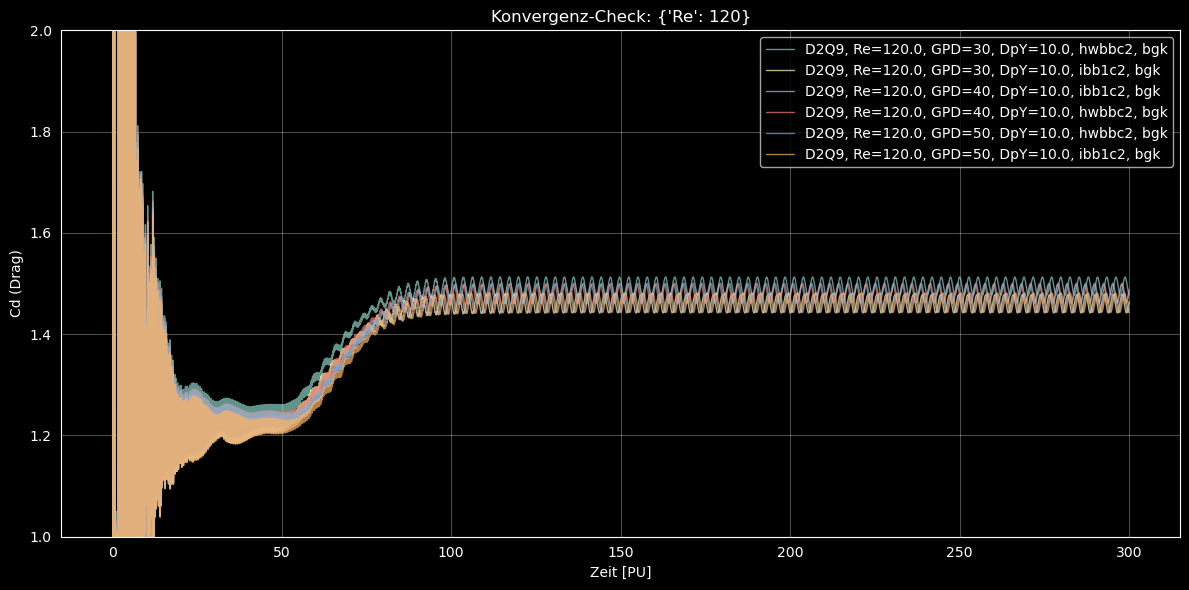

In [151]:
# PLOTTE Convergenz-Gruppe und Checke für konvergierten Bereich!

plot_convergence_group(master_summary, OUTPUT_MERGED, criteria={"Re": 120}, y_lim=(1, 2), t_max_view=None)

#### DUPLIKATE wegen unterschiedlicher BC-Benennung erkennen (c2-Variante) und aussortieren/archivieren

In [15]:
# DUPLIKATE wegen unterscheidlicher BC-Benennung finden (c2 Variante...)

def find_bc_duplicates(summary_df):
    """
    Findet Simulationen, die physikalisch identisch sind, aber unterschiedliche
    Namen für die Randbedingungen (bc_type) haben.
    """
    df = summary_df.copy()

    # 1. Normalisierungs-Regeln definieren
    # Wir mappen alle Varianten auf einen einheitlichen Standard-Namen
    bc_map = {
        'ibb1c2': 'ibb1',   # ibb1c2 wird zu ibb1
        'fwbbc':  'fwbb',   # fwbbc wird zu fwbb
        'hwbbc2': 'hwbb',   # hwbbc2 wird zu hwbb
        # Die "alten" Namen mappen auf sich selbst (implizit oder explizit)
        'ibb1':   'ibb1',
        'fwbb':   'fwbb',
        'hwbb':   'hwbb'
    }

    # 2. Neue Spalte für den Vergleich erstellen
    # Wenn ein bc_type nicht in der Map steht, behalten wir den Originalnamen
    df['bc_normalized'] = df['bc_type'].map(bc_map).fillna(df['bc_type'])

    # 3. Parameter für die Identität definieren (alles außer bc_type und Dateinamen)
    # DpZ nehmen wir nur rein, wenn es existiert (für 3D)
    ident_cols = ['Re', 'Ma', 'GPD', 'stencil', 'collision', 'DpY', 'bc_normalized']
    if 'DpZ' in df.columns:
        ident_cols.append('DpZ')

    # 4. Duplikate finden
    # keep=False sorgt dafür, dass ALLE Varianten angezeigt werden (nicht nur das Duplikat)
    duplicates = df[df.duplicated(subset=ident_cols, keep=False)].copy()

    if duplicates.empty:
        print("Keine BC-Duplikate gefunden. Alles sauber!")
        return pd.DataFrame()

    # 5. Schön sortieren für die Übersicht
    result = duplicates.sort_values(by=ident_cols)

    print(f"{len(result)} Einträge mit mehrdeutigen BC-Namen gefunden.")

    # Wir zeigen nur die relevanten Spalten an
    show_cols = ['Re', 'Ma', 'GPD', 'DpY', 'bc_type', 'real_time_end', 'file_name']
    return result[show_cols]

# --- ANWENDUNG ---
# duplicates_df = find_bc_duplicates(master_summary)
# display(duplicates_df)

In [99]:
duplicates_df = find_bc_duplicates(master_summary)
display(duplicates_df)

Keine BC-Duplikate gefunden. Alles sauber!


""


In [100]:
duplicates_df.to_csv("/mnt/ScratchHDD2/MBille/01_LBM_CP-data/"+ "duplicates_bc-naming.csv", index=False)

##### Aussortieren und Archivieren der Duplikate:

In [16]:
# AUSSORTIEREN/ARCHIVIEREN

def archive_bc_duplicates(summary_df, merged_dir, dry_run=True):
    """
    Identifiziert physikalisch identische Simulationen (trotz unterschiedlicher BC-Namen),
    behält diejenige mit der längsten Laufzeit und verschiebt die anderen in einen 'archive'-Ordner.
    """
    merged_path = Path(merged_dir)
    archive_path = merged_path / "archive"

    # Sicherstellen, dass der Archiv-Ordner existiert (nur wenn wir wirklich verschieben)
    if not dry_run:
        archive_path.mkdir(exist_ok=True)

    # 1. Normalisierung (wie in der Find-Funktion)
    df = summary_df.copy()
    bc_map = {
        'ibb1c2': 'ibb1', 'fwbbc': 'fwbb', 'hwbbc2': 'hwbb',
        'ibb1': 'ibb1',   'fwbb': 'fwbb',  'hwbb': 'hwbb'
    }
    df['bc_normalized'] = df['bc_type'].map(bc_map).fillna(df['bc_type'])

    # Identifikations-Spalten
    ident_cols = ['Re', 'Ma', 'GPD', 'stencil', 'collision', 'DpY', 'bc_normalized']
    if 'DpZ' in df.columns: ident_cols.append('DpZ')

    # 2. Gruppen finden und die "Verlierer" identifizieren
    files_to_move = []

    # Wir gruppieren nach den physikalischen Parametern
    for _, group in df.groupby(ident_cols):
        if len(group) > 1:
            # Sortieren: Die längste Simulation (real_time_end) kommt nach oben
            # Bei Gleichstand gewinnt die alphabetisch letzte (oft neueres Datum/Name)
            sorted_group = group.sort_values(
                by=['real_time_end', 'file_name'],
                ascending=[False, False]
            )

            # Der Gewinner (Index 0) bleibt, der Rest (Index 1 bis Ende) fliegt raus
            winner = sorted_group.iloc[0]
            losers = sorted_group.iloc[1:]

            for _, loser in losers.iterrows():
                files_to_move.append({
                    'file': loser['file_name'],
                    'reason': f"Duplikat von {winner['file_name']} (Laufzeit: {loser['real_time_end']} vs {winner['real_time_end']})"
                })

    # 3. Aktion ausführen
    if not files_to_move:
        print("Keine Duplikate zum Verschieben gefunden.")
        return

    print(f"Gefunden: {len(files_to_move)} Dateien zum Archivieren.")

    for item in files_to_move:
        src = merged_path / item['file']
        dst = archive_path / item['file']

        if dry_run:
            print(f"[DRY RUN] Würde verschieben: {item['file']}")
            print(f"           -> Grund: {item['reason']}")
        else:
            if src.exists():
                try:
                    shutil.move(str(src), str(dst))
                    print(f"[ARCHIVED] {item['file']}")
                except Exception as e:
                    print(f"Fehler beim Verschieben von {item['file']}: {e}")
            else:
                print(f"Datei nicht gefunden (schon weg?): {item['file']}")

    if not dry_run:
        print(f"\nFertig. {len(files_to_move)} Dateien liegen jetzt in {archive_path}")
        print("WICHTIG: Bitte erstelle jetzt dein master_summary neu, damit die archivierten Dateien dort nicht mehr auftauchen!")

# --- ANWENDUNG ---

# 1. Erstmal schauen, was passieren würde (Sicherheits-Modus)
# archive_bc_duplicates(master_summary, OUTPUT_MERGED, dry_run=True)

# 2. Wenn die Ausgabe logisch aussieht -> Ernst machen:
# archive_bc_duplicates(master_summary, OUTPUT_MERGED, dry_run=False)

# 3. GANZ WICHTIG DANACH: Index aktualisieren!
# master_summary = create_summary_from_merged_files(OUTPUT_MERGED)

In [101]:
archive_bc_duplicates(master_summary, OUTPUT_MERGED, dry_run=True)

Keine Duplikate zum Verschieben gefunden.


In [46]:
# aktualisiere Master_summary
master_summary = create_summary_from_merged_files(OUTPUT_MERGED)

Analysiere 818 Master-Dateien...


In [47]:
# speichere Master-Summary
master_summary.to_csv("/mnt/ScratchHDD2/MBille/01_LBM_CP-data/" + "master_overview_merged.csv", index=False)

#### STATISTICAL ANALYSIS


#### FREQ-SINUS-Fit für Strouhal Zahl

In [3]:
def fit_dominant_frequency(t, y):
    """
    Bestimmt die Frequenz durch Anpassen einer Sinus-Funktion:
    y(t) = A * sin(2*pi*f*t + phi) + offset
    """
    # 1. Vorbereitung: Linearen Trend und Mittelwert entfernen für stabilen Fit
    y_centered = detrend(y, type='constant')

    # 2. Initial Guess mittels FFT (Schnelle Schätzung)
    dt = np.mean(np.diff(t))
    n = len(t)
    freqs = np.fft.rfftfreq(n, d=dt)
    fft_vals = np.abs(np.fft.rfft(y_centered))

    # Peak im FFT Spektrum finden (Index ignorieren wir bei f=0)
    idx_peak = np.argmax(fft_vals[1:]) + 1
    f_guess = freqs[idx_peak]
    amp_guess = np.std(y_centered) * 2**0.5

    # 3. Der Fit-Modell (Sinus)
    def sine_model(t, A, f, phi, offset):
        return A * np.sin(2 * np.pi * f * t + phi) + offset

    # 4. Optimierung (Curve Fit)
    # Wir geben dem Optimizer Starthilfe mit unseren FFT-Schätzungen
    try:
        p0 = [amp_guess, f_guess, 0, np.mean(y)] # in manuellem Original wurden hier (0.7, 0.2, 0.5, 0= verwendet...
        popt, pcov = curve_fit(sine_model, t, y, p0=p0, maxfev=10000)

        f_fitted = abs(popt[1]) # Frequenz ist Parameter Nr. 2
        return f_fitted
    except Exception as e:
        # Fallback auf FFT, falls Fit nicht konvergiert (z.B. bei chaotischem Signal)
        return f_guess

#### Statistik-Analyse

In [7]:
def get_t_start(row):
    """
    Hier definierst du deine 'semi-manuellen' Regeln.
    Die Funktion bekommt eine Zeile aus der Master-Summary (mit Re, Ma, etc.)
    und gibt den Startzeitpunkt zurück.
    """

    # Re40/200, DpY19 (GPD)
    if row["Re"] == 40 and row["DpY"] == 19:
        return 50
    if row["Re"] == 200 and row["DpY"] == 19:
        return 100

    # Re40, gpd30 (DpY)
    if row["Re"] == 40 and row["GPD"] ==30:
        if 10 <= row["DpY"] <= 80: # == 10 or row["DpY"] == 19 or row["DpY"] == 20 or row["DpY"] == 40 or row["DpY"] == 60 or row["DpY"] == 80:
            return 150
        if row["DpY"] == 200:
            return 300

    # Re200, gpd30 (DpY)
    if row["Re"] == 200 and row["GPD"] == 30:
        return 200

    # GPD50, DpY50 (2D vs. literature)
    if row["GPD"] == 50 and row["DpY"] == 50:
        if 10 <= row["Re"] <= 40:
            return 250
        if row["Re"] == 50:
            return 900
        if 70 <= row["Re"] <= 90:
            return 250
        if 100 <= row["Re"] <= 300:
            return 150
        # HIER FÄLLT Re60 raus...
        if row["Re"] == 60:
            return 250

    # GPD30, DpY10 (2D vs. 3D compare)
    if row["GPD"] == 30 and row["DpY"] == 10 and row["Re"] < 1000:
        if row["DpZ"] == 3 and row["Re"] >= 200:
            return 1200 # 3D # first was 500
        else:
            return 200 # 2D

    # Re3900
    if row["Re"] == 3900:
        return 50

    # EXTRA
    if row["Re"] == 50 and row["GPD"] == 50:
        return 800
    if row["Re"] == 40 and row["GPD"] == 20:
        if row["DpY"] <=100:
            return 100
        else:
            return 300
    if row["Re"] == 200 and row["GPD"] == 42:
        return 75
    if row["Re"] == 200 and row["DpY"] == 10:
        return 100
    if (row["GPD"] == 40 or row["GPD"] == 50) and row["Re"] >= 100:
        return 200
    if row["Re"] == 200 and row["GPD"] == 20:
        if row["DpY"] <=100:
            return 100
        else:
            return 160
    if row["Re"] > 200 and row["GPD"] > 30 and row["DpY"] == 10:
        if row["DpZ"] == 1:
            return 200
        if row["DpZ"] == 3:
            return 250
        else:
            return 100

    print(f"(!) get_t_start(row): keine Zuordnung! return t_start = 99.0; Dataset: Re: {row['Re']}, GPD: {row['GPD']}, DpY: {row['DpY']}, DpZ: {row['DpZ']}, BC: {row['bc_type']}, COLL: {row['collision']}")
    return 99.0 # Default Fallback

def compile_full_statistics(summary_df, merged_dir):
    stats_results = []
    merged_path = Path(merged_dir)

    print(f"Berechne Statistik für {len(summary_df)} Simulationen...")

    for idx, row in summary_df.iterrows():
        # Basis-Namen rekonstruieren (ohne _drag.csv Endung)
        # Wir nehmen an, dass 'file_name' in der Summary z.B. "Re200..._drag.csv" ist
        base_name = row['file_name'].replace("_drag.csv", "").replace("_lift.csv", "")

        # Pfade
        f_drag = merged_path / f"{base_name}_drag.csv"
        f_lift = merged_path / f"{base_name}_lift.csv"

        # Startzeit bestimmen
        t_start = get_t_start(row)

        # Ergebnis-Dictionary initialisieren (mit Metadaten)
        res = row.to_dict()
        res['t_start_stat'] = t_start

        # --- DRAG ANALYSE ---
        if f_drag.exists():
            df_d = pd.read_csv(f_drag)
            # Filtern
            df_d = df_d[df_d['timePU'] >= t_start]

            if not df_d.empty:
                # in manuellem Original wurde hier noch ein peakfinder verwendet und für eine ganzahlige Zahl Perioden dann die Durchschnitte der min-Peaks und der Max-Peaks berechnet.
                # -> das könnte man hier noch als eigene Zeile und ausgelagerte Funktion einfügen..
                # res['Cd_peak_min'], res['Cd_peak_max'], res['Cd_mean_periodcorrected]
                vals = df_d['Cd']
                res['Cd_mean'] = vals.mean()
                res['Cd_min'] = vals.min()
                res['Cd_max'] = vals.max()
                res['Cd_stdev'] = vals.std()
                res['Cd_amp'] = (res['Cd_max'] - res['Cd_min']) / 2

                # Unsicherheit (Standard Error & Confidence Interval)
                s_err = sem(vals)
                res['Cd_sem'] = s_err
                res['Cd_ci_lower'] = res['Cd_mean'] - 1.96 * s_err
                res['Cd_ci_upper'] = res['Cd_mean'] + 1.96 * s_err
            else:
                print(f"Warnung: {base_name}_drag.csv hat keine Daten nach t={t_start}")

        # --- LIFT ANALYSE ---
        if f_lift.exists():
            df_l = pd.read_csv(f_lift)
            # Filtern
            df_l = df_l[df_l['timePU'] >= t_start]

            if not df_l.empty:
                vals = df_l['Cl']
                res['Cl_mean'] = vals.mean() # Sollte ~0 sein bei Zylinder
                res['Cl_min'] = vals.min()
                res['Cl_max'] = vals.max()
                res['Cl_stdev'] = vals.std()
                res['Cl_p2p'] = vals.max() - vals.min()

                # --- FREQUENZ ANALYSE (STROUHAL) ---
                # Wir machen das nur, wenn das Signal auch schwankt (z.B. Re > 47)
                # und genügend Datenpunkte da sind
                if res['Cl_p2p'] > 1e-4 and len(vals) > 50:
                    try:
                        # es wäre noch schön zu wissen, ob FFT oder Sine-Fit angewendet wurden, das sollte entsprechend als zweiter Return-Wert zurückgegeben werden! 'fft' oder 'sine-fit' als f_type
                        f_dom = fit_dominant_frequency(df_l['timePU'].values, vals.values)
                        res['f_dom'] = f_dom

                        # Strouhal = f * D / U
                        # Annahme: D=1.0 und U=Ma (in Lattice Units ist U oft Ma * cs oder explizit gegeben)
                        # ACHTUNG: Hier musst du prüfen, wie deine Geschwindigkeit definiert ist!
                        # In Lettuce ist U meistens Ma * cs (cs=1/sqrt(3))
                        # ODER du hast U_lattice direkt.
                        # Wenn 'timePU' physikalische Einheiten sind (t * U / D), dann ist f_dom direkt St!

                        # Fall A: timePU ist dimensionslos (t*U/D) -> f_dom = St
                        res['St'] = f_dom

                    except Exception as e:
                        res['St'] = np.nan
                else:
                    res['St'] = 0.0 # Stationär

        stats_results.append(res)

    return pd.DataFrame(stats_results)

# --- AUSFÜHRUNG ---
# df_stats = compile_full_statistics(final_master_summary, OUTPUT_MERGED)
# df_stats.to_csv("simulation_statistics_results.csv", index=False)
# print("Statistik fertig!")

### tests St-fit

In [8]:
# --- 1. Die mathematische Funktion (Hier deine eigene einfügen oder diese nutzen) ---
def fit_dominant_frequency_full_parms(t, y):
    """
    Passt eine Sinus-Funktion y = A * sin(2*pi*f*t + phi) + offset an.
    Gibt die Frequenz f, Amplitude A, Phase phi und Offset zurück.
    """
    # Vorbereitung: Trend entfernen für stabileren Fit
    y_centered = detrend(y, type='constant')

    # FFT für Startwerte (Initial Guess)
    dt = np.mean(np.diff(t))
    n = len(t)
    freqs = np.fft.rfftfreq(n, d=dt)
    fft_vals = np.abs(np.fft.rfft(y_centered))
    idx_peak = np.argmax(fft_vals[1:]) + 1

    f_guess = freqs[idx_peak]
    amp_guess = np.std(y_centered) * 2**0.5

    # Modell definieren
    def sine_model(t, A, f, phi, offset):
        return A * np.sin(2 * np.pi * f * t + phi) + offset

    # Curve Fit durchführen
    try:
        p0 = [amp_guess, f_guess, 0, np.mean(y)]
        # Bounds verhindern, dass die Frequenz negativ wird
        popt, _ = curve_fit(sine_model, t, y, p0=p0, maxfev=10000)
        return popt # [A, f, phi, offset]
    except Exception:
        return None

# --- 2. Das Test-Skript (Visualisierung) ---
def verify_strouhal_fit(summary_df, merged_dir, Re_test=200, t_start=100):
    """
    Lädt eine Simulation, fittet den Sinus und zeigt das Ergebnis grafisch.
    """
    # Eine passende Datei finden
    match = summary_df[summary_df['Re'] == Re_test].iloc[0] # Nimm die erste Re=200
    file_name = match['file_name'].replace("_drag.csv", "_lift.csv").replace("_lift.csv", "_lift.csv")
    file_path = Path(merged_dir) / file_name

    if not file_path.exists():
        print(f"Datei nicht gefunden: {file_path}")
        return

    # Daten laden & schneiden
    df = pd.read_csv(file_path)
    df = df[df['timePU'] >= t_start]

    t_data = df['timePU'].values
    y_data = df['Cl'].values

    # Fit durchführen
    params = fit_dominant_frequency_full_parms(t_data, y_data)

    if params is None:
        print("Fit fehlgeschlagen!")
        return

    A, f, phi, offset = params

    # Ergebnis plotten
    plt.figure(figsize=(10, 5))
    plt.plot(t_data, y_data, 'b-', alpha=0.5, label='Original Cl Daten')

    # Die gefittete Kurve berechnen
    y_fit = A * np.sin(2 * np.pi * f * t_data + phi) + offset
    plt.plot(t_data, y_fit, 'r--', linewidth=2, label=f'Fit (f={f:.4f})')

    plt.title(f"Strouhal-Check: Re={Re_test}\nGefundene Frequenz: {f:.4f}")
    plt.xlabel("Zeit [PU]")
    plt.ylabel("Cl")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Zoom in einen kleinen Bereich (z.B. 5 Perioden), damit man Details sieht
    period = 1/f
    plt.xlim(t_data[0], t_data[0] + 5*period)

    plt.show()
    print(f"Datei: {file_name}")
    print(f"Ergebnis: Strouhal St = {f} (wenn timePU konvektive Zeit ist)")

# --- 3. Ausführen ---
# verify_strouhal_fit(master_summary, OUTPUT_MERGED, Re_test=200, t_start=100)

#### führe verify St-Fit aus...

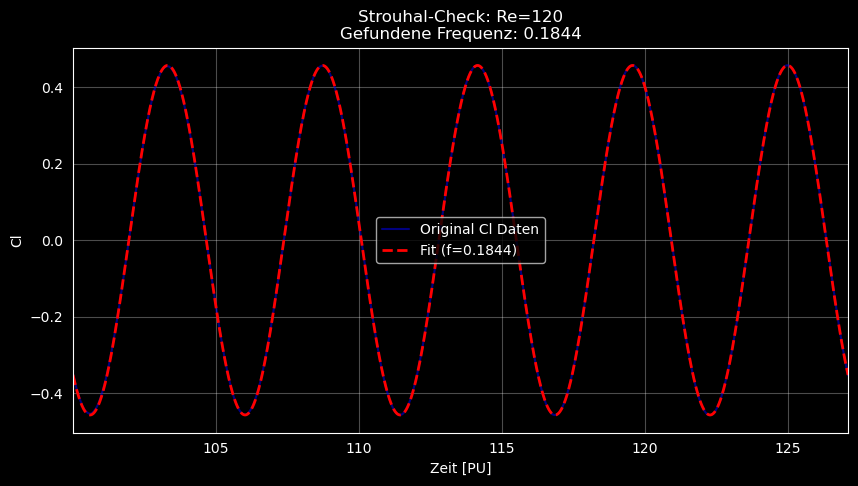

Datei: Re120.0_Ma0.05_GPD30_D2Q9_DpY10.0_BC_hwbbc2_Coll_bgk_T300_lift.csv
Ergebnis: Strouhal St = 0.1843901005844408 (wenn timePU konvektive Zeit ist)


In [154]:
verify_strouhal_fit(master_summary, OUTPUT_MERGED, Re_test=120, t_start=100)

#### AUSFÜHREN STATISTIK (komplett)

In [9]:
master_summary = pd.read_csv("/mnt/ScratchHDD2/MBille/01_LBM_CP-data/" + "master_overview_merged.csv")
df_stats = compile_full_statistics(master_summary, OUTPUT_MERGED)
df_stats.to_csv("/mnt/ScratchHDD2/MBille/01_LBM_CP-data/" + "simulation_statistics_results.csv", index=False)
print("Statistik fertig!")

Berechne Statistik für 815 Simulationen...
Warnung: Re220.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_hwbbc2_Coll_kbc_DpZ3.0_T972_drag.csv hat keine Daten nach t=1200
Warnung: Re220.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_ibb1c2_Coll_kbc_DpZ3.0_T971_drag.csv hat keine Daten nach t=1200
Warnung: Re240.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_ibb1c2_Coll_kbc_DpZ3.0_T971_drag.csv hat keine Daten nach t=1200
Warnung: Re240.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_hwbbc2_Coll_kbc_DpZ3.0_T971_drag.csv hat keine Daten nach t=1200
Warnung: Re260.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_hwbbc2_Coll_kbc_DpZ3.0_T971_drag.csv hat keine Daten nach t=1200
Warnung: Re260.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_ibb1c2_Coll_kbc_DpZ3.0_T970_drag.csv hat keine Daten nach t=1200
Warnung: Re280.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_hwbbc2_Coll_kbc_DpZ3.0_T971_drag.csv hat keine Daten nach t=1200
Warnung: Re280.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_ibb1c2_Coll_kbc_DpZ3.0_T971_drag.csv hat keine Daten nach t=1200
Warnung: Re300.0_Ma0.05_GPD30_D3Q27_DpY10.0_BC_ibb1c2_Coll_kb

In [20]:
df_stats = pd.read_csv("/mnt/ScratchHDD2/MBille/01_LBM_CP-data/" + "simulation_statistics_results.csv")

### Statistik-Tabellen

In [56]:
def create_statistics_table(stats_df, table_definitions, metrics_to_show):
    """
    Erzeugt eine saubere Übersichtstabelle basierend auf Filter-Kriterien.

    :param stats_df: Dein DataFrame mit allen Statistiken
    :param table_definitions: Liste von Dictionaries mit 'criteria' und (optional) 'label'
    :param metrics_to_show: Liste der Spaltennamen, die ausgegeben werden sollen
    """
    table_rows = []

    for idx, definition in enumerate(table_definitions):
        df_sub = stats_df.copy()
        criteria = definition.get('criteria', {})

        # 1. Daten filtern
        for col, val in criteria.items():
            if isinstance(val, (list, tuple)):
                df_sub = df_sub[df_sub[col].isin(val)]
            else:
                df_sub = df_sub[df_sub[col] == val]

        if df_sub.empty:
            print(f"⚠️ Warnung: Keine Daten gefunden für Kriterien: {criteria}")
            continue

        # 2. Spezielle Berechnungen "on the fly" (z.B. Amplitude)
        if 'Cd_amp' in metrics_to_show and 'Cd_amp' not in df_sub.columns:
            if 'Cd_max' in df_sub.columns and 'Cd_min' in df_sub.columns:
                df_sub['Cd_amp'] = df_sub['Cd_max'] - df_sub['Cd_min']

        if 'Cl_amp' in metrics_to_show and 'Cl_amp' not in df_sub.columns:
            if 'Cl_max' in df_sub.columns and 'Cl_min' in df_sub.columns:
                df_sub['Cl_amp'] = df_sub['Cl_max'] - df_sub['Cl_min']

        # Sortieren (meistens nach Reynolds-Zahl am sinnvollsten)
        if 'Re' in df_sub.columns:
            df_sub = df_sub.sort_values('Re')

        # 3. Werte extrahieren und formatieren
        for _, row_data in df_sub.iterrows():
            row_dict = {}

            # Einen Namen für die Zeile vergeben
            row_dict['Name'] = definition.get('label', f"Reihe {idx+1}")

            # Die Filter-Parameter eintragen (damit man weiß, was was ist)
            # (Wir nehmen Re immer mit auf, da es oft die Laufvariable ist)
            for k in criteria.keys():
                row_dict[k] = row_data.get(k)
            if 'Re' not in criteria and 'Re' in row_data:
                row_dict['Re'] = row_data['Re']

            # Die gewünschten Statistik-Werte eintragen und runden
            for metric in metrics_to_show:
                val = row_data.get(metric)
                if isinstance(val, float):
                    row_dict[metric] = round(val, 5) # Auf 5 Nachkommastellen runden
                else:
                    row_dict[metric] = val

            table_rows.append(row_dict)

    # DataFrame zurückgeben
    return pd.DataFrame(table_rows)

#### Fig. X - Re3900, GPD38 - Errbars

In [60]:
# 1. Welche Simulationen sollen in die Tabelle?
meine_tabellen_reihen = [
    {
        'label': 'REG FWBB',
        'criteria': {'stencil': 'D3Q27', 'Re': 3900, 'GPD': 38, 'DpY':10, 'DpZ':3, 'collision': 'reg', 'bc_type': ['fwbb', 'fwbbc']} # Listen gehen auch!
    },
    {
        'label': 'REG HWBB',
        'criteria': {'stencil': 'D3Q27', 'Re': 3900, 'GPD': 38, 'DpY':10, 'DpZ':3, 'collision': 'reg', 'bc_type': ['hwbb', 'hwbbc2']}
    },
    {
        'label': 'REG IBB',
        'criteria': {'stencil': 'D3Q27', 'Re': 3900, 'GPD': 38, 'DpY':10, 'DpZ':3, 'collision': 'reg', 'bc_type': ['ibb1', 'ibb1c2']} # Listen gehen auch!
    },

    #KBC
    {
        'label': 'KBC FWBB',
        'criteria': {'stencil': 'D3Q27', 'Re': 3900, 'GPD': 38, 'DpY':10, 'DpZ':3, 'collision': 'kbc', 'bc_type': ['fwbb', 'fwbbc']} # Listen gehen auch!
    },
    {
        'label': 'KBC HWBB',
        'criteria': {'stencil': 'D3Q27', 'Re': 3900, 'GPD': 38, 'DpY':10, 'DpZ':3, 'collision': 'kbc', 'bc_type': ['hwbb', 'hwbbc2']}
    },
    {
        'label': 'KBC IBB',
        'criteria': {'stencil': 'D3Q27', 'Re': 3900, 'GPD': 38, 'DpY':10, 'DpZ':3, 'collision': 'kbc', 'bc_type': ['ibb1', 'ibb1c2']} # Listen gehen auch!
    },
]

# 2. Welche Werte willst du ablesen?
werte_die_ich_brauche = ['Cd_mean', 'Cd_stdev']

# 3. Tabelle generieren
df_paper_table = create_statistics_table(df_stats, meine_tabellen_reihen, werte_die_ich_brauche)

# 4. Im Notebook anzeigen
display(df_paper_table)

,Name,stencil,Re,GPD,DpY,DpZ,collision,bc_type,Cd_mean,Cd_stdev
0,REG FWBB,D3Q27,3900.0,38,10.0,3.0,reg,fwbb,1.28361,0.03858
1,REG HWBB,D3Q27,3900.0,38,10.0,3.0,reg,hwbb,1.68244,1.76355
2,REG IBB,D3Q27,3900.0,38,10.0,3.0,reg,ibb1,1.04516,0.03654
3,KBC FWBB,D3Q27,3900.0,38,10.0,3.0,kbc,fwbb,1.60646,0.11624
4,KBC HWBB,D3Q27,3900.0,38,10.0,3.0,kbc,hwbb,1.67483,0.38177
5,KBC IBB,D3Q27,3900.0,38,10.0,3.0,kbc,ibb1,1.11538,0.03696


In [62]:
# 1. Wie sollen die Spalten im echten Paper heißen?
latex_namen = {
    'Name': r'Sim.',
    'Cd_mean': r'$C_{D, mean}$',
    'Cd_stdev': r'$\sigma(C_D)$',
}

# 2. Zuerst die gewünschten Spalten auswählen, dann umbenennen, dann als LaTeX ausgeben
latex_code = (df_paper_table[['Name', 'Cd_mean', 'Cd_stdev']].rename(columns=latex_namen).to_latex(index=False, escape=False, float_format="%.4f"))

print(latex_code)

\begin{tabular}{lrr}
\toprule
    Sim. &  $C_{D, mean}$ &  $\sigma(C_D)$ \\
\midrule
REG FWBB &         1.2836 &         0.0386 \\
REG HWBB &         1.6824 &         1.7635 \\
 REG IBB &         1.0452 &         0.0365 \\
KBC FWBB &         1.6065 &         0.1162 \\
KBC HWBB &         1.6748 &         0.3818 \\
 KBC IBB &         1.1154 &         0.0370 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_13810/3867719874.py:9: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_code = (df_paper_table[['Name', 'Cd_mean', 'Cd_stdev']].rename(columns=latex_namen).to_latex(index=False, escape=False, float_format="%.4f"))


#### Fig. 15a - Drag TABELLE

In [70]:
# 1. Welche Simulationen sollen in die Tabelle?
meine_tabellen_reihen = [
    {
        'label': '2D HWBB',
        'criteria': {'stencil': 'D2Q9', 'DpY': 10,'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2'], 'Re': list(np.linspace(100,300, 11, endpoint=True))}
    },
    {
        'label': '2D IBB',
        'criteria': {'stencil': 'D2Q9', 'DpY': 10,'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2'], 'Re': list(np.linspace(100,300, 11, endpoint=True))}
    },
    {
        'label': '3D HWBB',
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))}
    },
    {
        'label': '3D IBB',
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
    },

]

# 2. Welche Werte willst du ablesen?
werte_die_ich_brauche = ['Cd_mean', 'Cd_stdev']

# 3. Tabelle generieren
df_paper_table = create_statistics_table(df_stats, meine_tabellen_reihen, werte_die_ich_brauche)

# 4. Im Notebook anzeigen
display(df_paper_table)

,Name,stencil,DpY,GPD,collision,bc_type,Re,Cd_mean,Cd_stdev
0,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,100.0,1.51510,0.00601
1,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,120.0,1.49467,0.01254
2,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,140.0,1.48547,0.02217
3,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,160.0,1.48260,0.02868
4,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,180.0,1.48345,0.03254
5,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,200.0,1.48688,0.03538
6,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,220.0,1.49214,0.03903
7,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,240.0,1.49782,0.04427
8,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,260.0,1.50418,0.05113
9,2D HWBB,D2Q9,10.0,30,bgk,hwbbc2,280.0,1.51110,0.05898


In [71]:
# 1. Wie sollen die Spalten im echten Paper heißen?
latex_namen = {
    'Name': r'Sim.',
    'Re': r'$Re$',
    'Cd_mean': r'$C_{D, mean}$',
    'Cd_stdev': r'$\sigma(C_D)$',
}

# 2. Zuerst die gewünschten Spalten auswählen, dann umbenennen, dann als LaTeX ausgeben
latex_code = (df_paper_table[['Name', 'Re', 'Cd_mean', 'Cd_stdev']].rename(columns=latex_namen).to_latex(index=False, escape=False, float_format="%.4f"))

print(latex_code)

\begin{tabular}{lrrr}
\toprule
   Sim. &     $Re$ &  $C_{D, mean}$ &  $\sigma(C_D)$ \\
\midrule
2D HWBB & 100.0000 &         1.5151 &         0.0060 \\
2D HWBB & 120.0000 &         1.4947 &         0.0125 \\
2D HWBB & 140.0000 &         1.4855 &         0.0222 \\
2D HWBB & 160.0000 &         1.4826 &         0.0287 \\
2D HWBB & 180.0000 &         1.4834 &         0.0325 \\
2D HWBB & 200.0000 &         1.4869 &         0.0354 \\
2D HWBB & 220.0000 &         1.4921 &         0.0390 \\
2D HWBB & 240.0000 &         1.4978 &         0.0443 \\
2D HWBB & 260.0000 &         1.5042 &         0.0511 \\
2D HWBB & 280.0000 &         1.5111 &         0.0590 \\
2D HWBB & 300.0000 &         1.5185 &         0.0671 \\
 2D IBB & 100.0000 &         1.4827 &         0.0049 \\
 2D IBB & 120.0000 &         1.4602 &         0.0127 \\
 2D IBB & 140.0000 &         1.4487 &         0.0206 \\
 2D IBB & 160.0000 &         1.4425 &         0.0248 \\
 2D IBB & 180.0000 &         1.4411 &         0.0270 \\
 2D IBB 

/tmp/ipykernel_13810/386686546.py:10: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_code = (df_paper_table[['Name', 'Re', 'Cd_mean', 'Cd_stdev']].rename(columns=latex_namen).to_latex(index=False, escape=False, float_format="%.4f"))


### STATISTIK-PLOTTING

In [10]:
def plot_statistics_group(stats_df, x_col, y_col, criteria=None, yerr_col=None, hue_col=None):
    """
    Plottet statistische Größen übereinander (inkl. Fehlerbalken).

    x_col:    Spalte für die X-Achse (z.B. 'Re', 'GPD')
    y_col:    Spalte für die Y-Achse (z.B. 'Cd_mean', 'St')
    criteria: Dictionary zum Filtern (z.B. {'stencil': 'D2Q9', 'DpY': 50.0})
    yerr_col: (Optional) Spalte für Fehlerbalken (z.B. 'Cd_sem' oder 'Cd_stdev')
    hue_col:  (Optional) Spalte zur farblichen Trennung als verschiedene Linien (z.B. 'Ma')
    """
    df = stats_df.copy()

    # 1. Filtern der Daten nach Kriterien
    if criteria:
        for col, val in criteria.items():
            if isinstance(val, (list, tuple)):
                df = df[df[col].isin(val)]
            else:
                df = df[df[col] == val]

    if df.empty:
        print(f"Keine Daten für die Kriterien {criteria} gefunden.")
        return

    # 2. Plot initialisieren
    plt.figure(figsize=(10, 6))

    # 3. Plotten (mit oder ohne Gruppierung/Farben)
    if hue_col and hue_col in df.columns:
        # Wir gruppieren nach der hue_col (z.B. für jede Mach-Zahl eine eigene Linie)
        groups = df.groupby(hue_col)
        for name, group in groups:
            # Wichtig: Nach X sortieren, sonst springen die Linien wild hin und her
            group = group.sort_values(by=x_col)

            if yerr_col and yerr_col in group.columns:
                plt.errorbar(group[x_col], group[y_col], yerr=group[yerr_col],
                             marker='o', linestyle='-', label=f"{hue_col}={name}", capsize=4)
            else:
                plt.plot(group[x_col], group[y_col], marker='o', linestyle='-', label=f"{hue_col}={name}")
    else:
        # Alles in eine einzige Linie plotten
        df = df.sort_values(by=x_col)

        if yerr_col and yerr_col in df.columns:
            plt.errorbar(df[x_col], df[y_col], yerr=df[yerr_col],
                         marker='o', linestyle='-', label=y_col, capsize=4, color='red')
        else:
            plt.plot(df[x_col], df[y_col], marker='o', linestyle='-', label=y_col, color='red')

    # 4. Plot hübsch machen
    criteria_str = ", ".join([f"{k}={v}" for k, v in criteria.items()]) if criteria else "Alle Daten"
    plt.title(f"{y_col} über {x_col}\nFilter: {criteria_str}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)

    # Wenn wir bei Re logarithmisch plotten wollen, hilft das oft (optional anpassbar)
    if x_col == 'Re' and df[x_col].max() > 1000:
        plt.xscale('log')

    plt.grid(True, alpha=0.3, which='both', linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.show()

#### ausführen

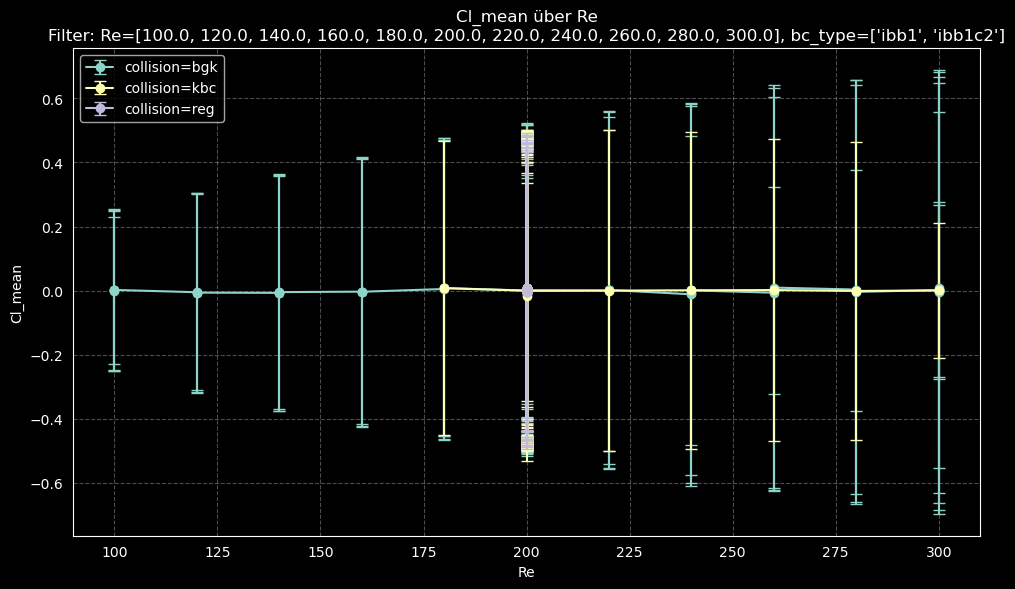

In [24]:
plot_statistics_group(
    df_stats, 
    x_col='Re',
    y_col='Cl_mean',
    yerr_col='Cl_stdev',
    criteria={"Re": list(np.linspace(100,300, 11, endpoint=True)), 'bc_type': ['ibb1','ibb1c2']},
    hue_col='collision'
)

#### zeige einzelne Simulation im dataframe:

In [82]:
meine_sim = df_stats[(df_stats["Re"]==40) & (df_stats["DpY"]==19)]
display(meine_sim)

,Re,Ma,GPD,stencil,DpY,DpZ,bc_type,collision,real_time_end,total_steps_recorded,...,Cd_sem,Cd_ci_lower,Cd_ci_upper,Cl_mean,Cl_min,Cl_max,Cl_stdev,Cl_p2p,St,f_dom
6,40.0,0.05,10,D2Q9,19.0,NaN,fwbbc,bgk,199.999907,69283,...,0.000007,1.672697,1.672723,-2.674530e-08,-0.000245,0.000206,0.000036,0.000451,3.182384,3.182384
7,40.0,0.05,10,D2Q9,19.0,NaN,hwbbc2,kbc,199.999907,69283,...,0.000007,1.687367,1.687394,-1.091542e-07,-0.000316,0.000277,0.000090,0.000593,173.205081,173.205081
8,40.0,0.05,10,D2Q9,19.0,NaN,fwbbc,reg,199.999907,69283,...,0.000007,1.685826,1.685852,-1.131859e-07,-0.000238,0.000196,0.000035,0.000434,3.182313,3.182313
9,40.0,0.05,10,D2Q9,19.0,NaN,ibb1c2,bgk,199.999907,69283,...,0.000006,1.645884,1.645909,1.047386e-07,-0.000232,0.000195,0.000035,0.000427,2.111544,2.111544
10,40.0,0.05,10,D2Q9,19.0,NaN,fwbbc,kbc,199.999907,69283,...,0.000008,1.688008,1.688041,-1.100348e-07,-0.004527,0.004559,0.001715,0.009086,85.232818,85.232818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,40.0,0.05,50,D2Q9,19.0,NaN,ibb1c2,bgk,199.999907,346411,...,0.000003,1.617489,1.617500,3.185229e-08,-0.000040,0.000032,0.000006,0.000071,0.000000,NaN
243,40.0,0.05,60,D2Q9,19.0,NaN,fwbbc,bgk,199.999907,415693,...,0.000003,1.621986,1.621996,2.453219e-08,-0.000033,0.000027,0.000005,0.000060,0.000000,NaN
244,40.0,0.05,60,D2Q9,19.0,NaN,ibb1c2,bgk,199.999907,415693,...,0.000003,1.617162,1.617172,2.668345e-08,-0.000033,0.000026,0.000005,0.000059,0.000000,NaN
245,40.0,0.05,100,D2Q9,19.0,NaN,fwbbc,bgk,199.999907,692821,...,0.000002,1.620458,1.620465,1.523233e-08,-0.000020,0.000016,0.000003,0.000036,0.000000,NaN


### Plotte für Paper

In [37]:
def plot_paper_figure(stats_df, series_list, global_settings=None, references=None):
    if global_settings is None: global_settings = {}

    # --- 1. DARK MODE FIX ---
    # Zwingt Matplotlib temporär in den Standard-Modus (schwarze Schrift)
    plt.style.use('default')

    figsize = global_settings.get('figsize', (10, 6))
    constrained = global_settings.get('constrained_layout', True)
    dpi = global_settings.get('dpi', 300)

    base_fs = global_settings.get('fontsize', 12)
    legend_fs = global_settings.get('legend_fontsize', 10)

    fig, ax1 = plt.subplots(figsize=figsize, constrained_layout=constrained, dpi=dpi)

    # Zwingt den Hintergrund explizit auf Weiß (keine Transparenz)
    fig.patch.set_facecolor('white')
    ax1.set_facecolor('white')

    default_style = global_settings.get('default_style', {})
    if 'linewidth' in global_settings: default_style['linewidth'] = global_settings['linewidth']
    if 'linestyle' in global_settings: default_style['linestyle'] = global_settings['linestyle']
    if 'markersize' in global_settings: default_style['markersize'] = global_settings['markersize']
    if 'markeredgewidth' in global_settings: default_style['markeredgewidth'] = global_settings['markeredgewidth']

    default_style.setdefault('linewidth', 1.5)
    default_style.setdefault('markersize', 6)

    # --- 2. Datenreihen plotten ---
    for i, series in enumerate(series_list):
        df_sub = stats_df.copy()
        criteria = series.get('criteria', {})
        for col, val in criteria.items():
            if isinstance(val, (list, tuple)): df_sub = df_sub[df_sub[col].isin(val)]
            else: df_sub = df_sub[df_sub[col] == val]

        if df_sub.empty: continue

        x_col, y_col, yerr_col = series.get('x'), series.get('y'), series.get('yerr')
        df_sub = df_sub.sort_values(by=x_col)

        # NEU: Erlaube einen x-Offset, um Balken nebeneinander zu stellen
        x_data = df_sub[x_col].astype(float) + series.get('x_offset', 0.0)

        style = default_style.copy()
        style.update(series.get('style', {}))

        if yerr_col and yerr_col in df_sub.columns:
            if 'capsize' not in style:
                style['capsize'] = global_settings.get('capsize', 4)
            # HIER x_data statt df_sub[x_col]
            ax1.errorbar(x_data, df_sub[y_col], yerr=df_sub[yerr_col], **style)
        else:
            style.pop('capsize', None)
            # HIER x_data statt df_sub[x_col]
            ax1.plot(x_data, df_sub[y_col], **style)

    # --- 3. Globale Plot-Einstellungen ---
    if 'title' in global_settings:
        ax1.set_title(global_settings['title'], fontsize=global_settings.get('title_fontsize', base_fs + 2))
    if 'xlabel' in global_settings:
        ax1.set_xlabel(global_settings['xlabel'], fontsize=base_fs)
    if 'ylabel' in global_settings:
        ax1.set_ylabel(global_settings['ylabel'], fontsize=base_fs)

    if global_settings.get('xscale') == 'log': ax1.set_xscale('log')
    if global_settings.get('yscale') == 'log': ax1.set_yscale('log')

    if 'xlim' in global_settings: ax1.set_xlim(global_settings['xlim'])
    if 'ylim' in global_settings: ax1.set_ylim(global_settings['ylim'])

    if 'xticks' in global_settings: ax1.set_xticks(global_settings['xticks'])
    if 'yticks' in global_settings: ax1.set_yticks(global_settings['yticks'])
    if global_settings.get('grid', True): ax1.grid()#True, alpha=0.3, which='both', linestyle='--')

    ax1.tick_params(axis='both', which='major', labelsize=base_fs)

    # --- 4. Referenzlinien & Rechte Ticks ---
    if references:
        ax2 = None
        for ref in references:
            ref_type = ref.get('type', 'hline')

            if ref_type == 'hline':
                y_val = ref['y']
                style = ref.get('style', {})
                ax1.axhline(y=y_val, **style)

            elif ref_type == 'ticks':
                if ax2 is None:
                    ax2 = ax1.twinx()
                    ax2.set_ylim(ax1.get_ylim())
                    if global_settings.get('yscale') == 'log':
                        ax2.set_yscale('log')
                    ax2.grid(False)

                y_vals = ref['y_list']
                tick_style = ref.get('style', {'color': 'r', 'direction': 'in', 'width': 1.2})

                ax2.set_yticks(y_vals)
                ax2.set_yticklabels([" "] * len(y_vals))
                ax2.tick_params(axis='y', **tick_style)

                if 'label' in ref:
                    legend_color = tick_style.get('color', 'r')
                    ax1.plot([], [], ls="", marker="_", color=legend_color, label=ref['label'])

    ax1.legend(loc=global_settings.get('legend_loc', 'best'),
               ncol=global_settings.get('legend_ncol', 1),
               fontsize=legend_fs)

    # --- 5. SPEICHERN ---
    save_path = global_settings.get('save_path')
    if save_path:
        # bbox_inches='tight' verhindert, dass Achsenbeschriftungen abgeschnitten werden
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white', transparent=False)
        print(f"✅ Plot gespeichert unter: {save_path}")

    plt.show()

#### Fig 5 a, Cd(GPD), Re40 (# PARAMETERS: Re40, DpY19, D2Q9)

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/drag_test.pdf


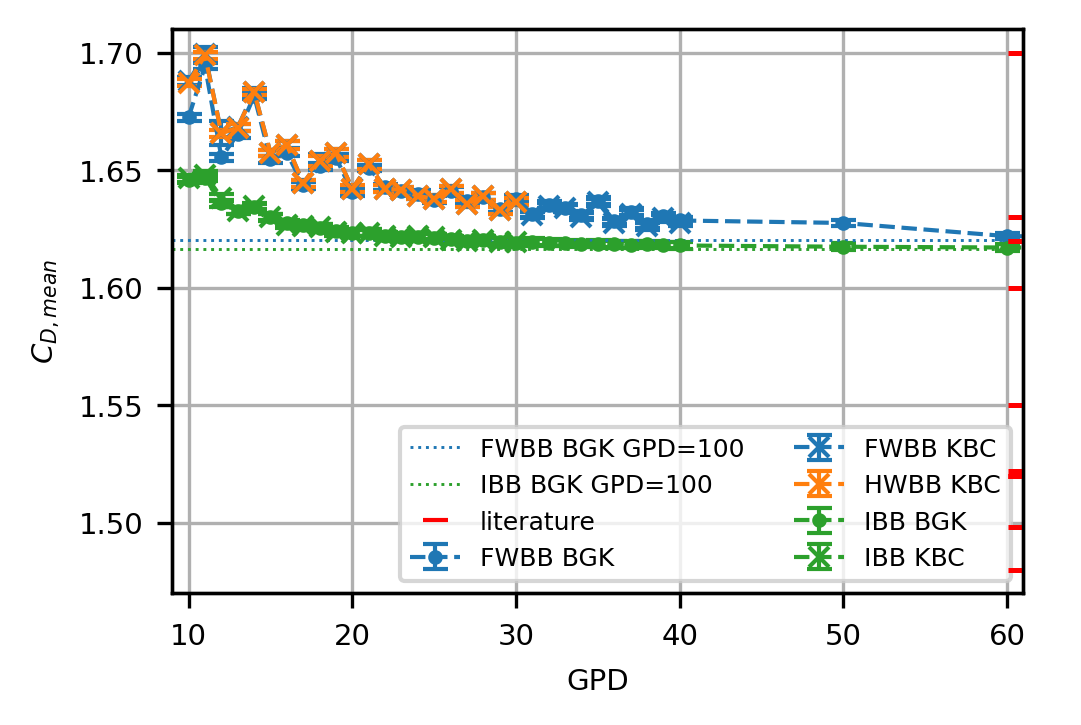

In [81]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # Deine "converged values" (Normale Linien durch den ganzen Plot)
    {
        'type': 'hline',
        'y': 1.62043666060609, # Hier deinen data[1,-1] Wert eintragen
        'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=100'}
    },
    {
        'type': 'hline',
        'y': 1.61664539391355, # Hier deinen data[5,-1] Wert eintragen
        'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=100'}
    },

    # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    {
        'type': 'ticks',
        'y_list': [1.7, 1.48, 1.522, 1.498, 1.52, 1.62, 1.6, 1.63, 1.52, 1.55, 1.52, 1.62],
        'label': 'literature',
        'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 6,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 2,           # Deine ncol=2 Anforderung aus der Legende!
    'legend_loc': 'lower right',
    'ylim': (1.47, 1.71),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'GPD',
    'ylabel': r'$C_{D,mean}$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (9,61),
    'linestyle': '--',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'capsize': 3,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'drag_test.pdf'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    {
        'criteria': {'stencil': 'D2Q9', 'Re': 40, 'DpY': 19, 'collision': 'bgk', 'bc_type': ['fwbb', 'fwbbc']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'style': {
            'label': 'FWBB BGK',
            'color': 'tab:blue',
            'marker': '.',
            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'Re': 40, 'DpY': 19, 'collision': 'kbc', 'bc_type': ['fwbb', 'fwbbc']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'style': {
            'label': 'FWBB KBC',
            'color': 'tab:blue',
            'marker': 'x',
            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'Re': 40, 'DpY': 19, 'collision': 'kbc', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'style': {
            'label': 'HWBB KBC',
            'color': 'tab:orange',
            'marker': 'x',
            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'Re': 40, 'DpY': 19, 'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'style': {
            'label': 'IBB BGK',
            'color': 'tab:green',
            'marker': '.',
            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'Re': 40, 'DpY': 19, 'collision': 'kbc', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'style': {
            'label': 'IBB KBC',
            'color': 'tab:green',
            'marker': 'x',
            }
    }
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen, references=meine_referenzen)

#### STATISTIKEN ÜBER EIN ENSEMBLE ANZEIGEN:


In [99]:
# 1. Definiere für welche Gruppe du das wissen willst (z.B. alle D2Q9)
criteria = {'stencil': 'D2Q9', 'Re': 40, 'DpY': 19, 'bc_type': ['hwbb', 'hwbbc2'], 'collision': 'bgk'}

# 2. Filtere das DataFrame (df_stats)
df_sub = df_stats.copy()
for col, val in criteria.items():
    if isinstance(val, (list, tuple)):
        df_sub = df_sub[df_sub[col].isin(val)]
    else:
        df_sub = df_sub[df_sub[col] == val]

# 3. Berechne die gewünschte "Errorbar-Größe"
# Variante A: Wenn deine Errorbars Peak-to-Peak (Max - Min) sind
errorbar_size = (df_sub['Cd_max'] - df_sub['Cd_min'])/2

# Variante B: Wenn deine Errorbars die Standardabweichung (Cd_stdev) sind
# errorbar_size = df_sub['Cd_stdev']
# (Multipliziere mit 2, falls du die Gesamtlänge von -sigma bis +sigma meinst)

# 4. Werte berechnen und schön ausdrucken
print(f"--- Auswertung für {criteria} ---")
print(f"Anzahl untersuchter Simulationen: {len(df_sub)}")
print(f"Kleinste Amplitude (Min):   {errorbar_size.min():.5f}")
print(f"Mittlere Amplitude (Mean):  {errorbar_size.mean():.5f}")
print(f"Größte Amplitude (Max):     {errorbar_size.max():.5f}")
print(f"Stdev Amplitude (stdev):  {errorbar_size.std():.5f}")

--- Auswertung für {'stencil': 'D2Q9', 'Re': 40, 'DpY': 19, 'bc_type': ['hwbb', 'hwbbc2'], 'collision': 'bgk'} ---
Anzahl untersuchter Simulationen: 0
Kleinste Amplitude (Min):   nan
Mittlere Amplitude (Mean):  nan
Größte Amplitude (Max):     nan
Stdev Amplitude (stdev):  nan


#### Fig 5 a, Cd(GPD), Re20 (# PARAMETERS: Re20, DpY19, D2Q9)

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/drag_test.pdf


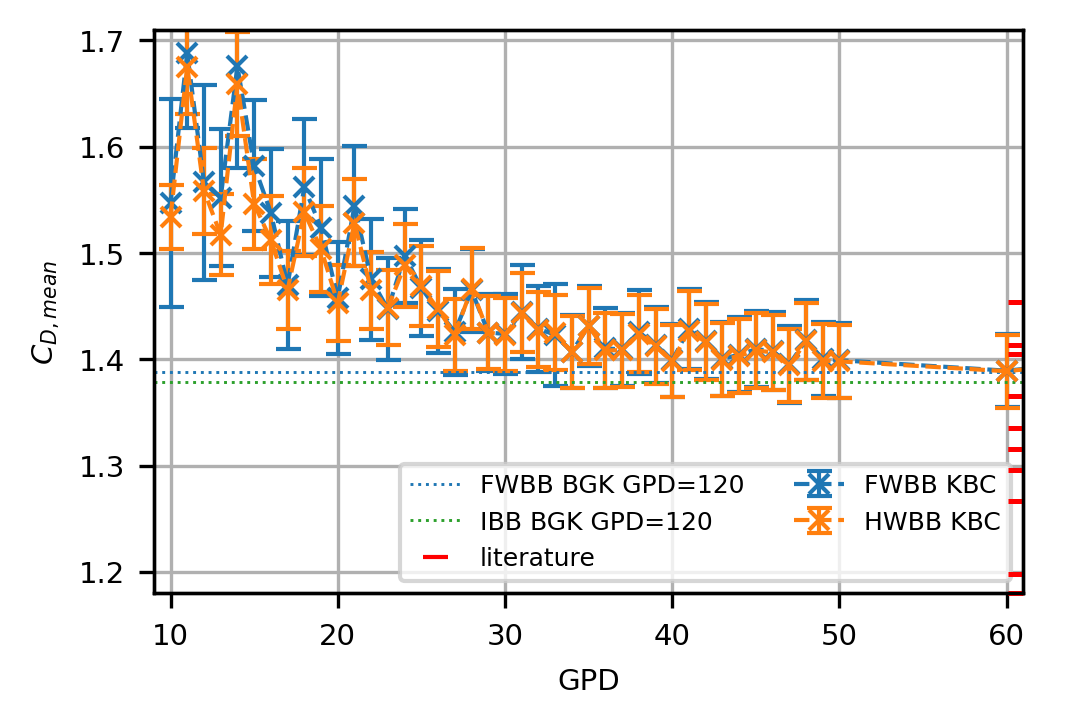

In [103]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # Deine "converged values" (Normale Linien durch den ganzen Plot)
    {
        'type': 'hline',
        'y': 1.38837589591116, # Hier deinen data[1,-1] Wert eintragen
        'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=120'}
    },
    {
        'type': 'hline',
        'y': 1.37895433114811, # Hier deinen data[5,-1] Wert eintragen
        'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=120'}
    },

    # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    {
        'type': 'ticks',
        'y_list': [1.4,1.31,1.19,1.31,1.33,1.172,1.29,1.45,1.26,1.36,1.4087],
        'label': 'literature',
        'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 6,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 2,           # Deine ncol=2 Anforderung aus der Legende!
    'legend_loc': 'lower right',
    'ylim': (1.18, 1.71),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'GPD',
    'ylabel': r'$C_{D,mean}$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (9,61),
    'linestyle': '--',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'capsize': 3,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'drag_test.pdf'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    # {
    #     'criteria': {'stencil': 'D2Q9', 'Re': 200, 'DpY': 19, 'collision': 'bgk', 'bc_type': ['fwbb', 'fwbbc']},
    #     'x': 'GPD',
    #     'y': 'Cd_mean',
    #     'yerr': 'Cd_stdev', # Die Fehlerbalken
    #     'style': {
    #         'label': 'FWBB BGK',
    #         'color': 'tab:blue',
    #         'marker': '.',
    #         }
    # },
    {
        'criteria': {'stencil': 'D2Q9', 'Re': 200, 'DpY': 19, 'collision': 'kbc', 'bc_type': ['fwbb', 'fwbbc']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'style': {
            'label': 'FWBB KBC',
            'color': 'tab:blue',
            'marker': 'x',
            }
    },
    # {
    #     'criteria': {'stencil': 'D2Q9', 'Re': 200, 'DpY': 19, 'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2']},
    #     'x': 'GPD',
    #     'y': 'Cd_mean',
    #     'yerr': 'Cd_stdev', # Die Fehlerbalken
    #     'style': {
    #         'label': 'HWBB BGK',
    #         'color': 'tab:orange',
    #         'marker': '.',
    #         }
    # },
    {
        'criteria': {'stencil': 'D2Q9', 'Re': 200, 'DpY': 19, 'collision': 'kbc', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'style': {
            'label': 'HWBB KBC',
            'color': 'tab:orange',
            'marker': 'x',
            }
    },
    # {
    #     'criteria': {'stencil': 'D2Q9', 'Re': 200, 'DpY': 19, 'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
    #     'x': 'GPD',
    #     'y': 'Cd_mean',
    #     'yerr': 'Cd_stdev', # Die Fehlerbalken
    #     'style': {
    #         'label': 'IBB BGK',
    #         'color': 'tab:green',
    #         'marker': '.',
    #         }
    # },
    # {
    #     'criteria': {'stencil': 'D2Q9', 'Re': 200, 'DpY': 19, 'collision': 'kbc', 'bc_type': ['ibb1', 'ibb1c2']},
    #     'x': 'GPD',
    #     'y': 'Cd_mean',
    #     'yerr': 'Cd_stdev', # Die Fehlerbalken
    #     'style': {
    #         'label': 'IBB KBC',
    #         'color': 'tab:green',
    #         'marker': 'x',
    #         }
    # }
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen, references=meine_referenzen)

#### Fig. 13: transition to 3D (2D vs. 3D): Cd, Cl., St vs. Re for 2D/3D

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/Fig13a_Drag_Err_New.pdf


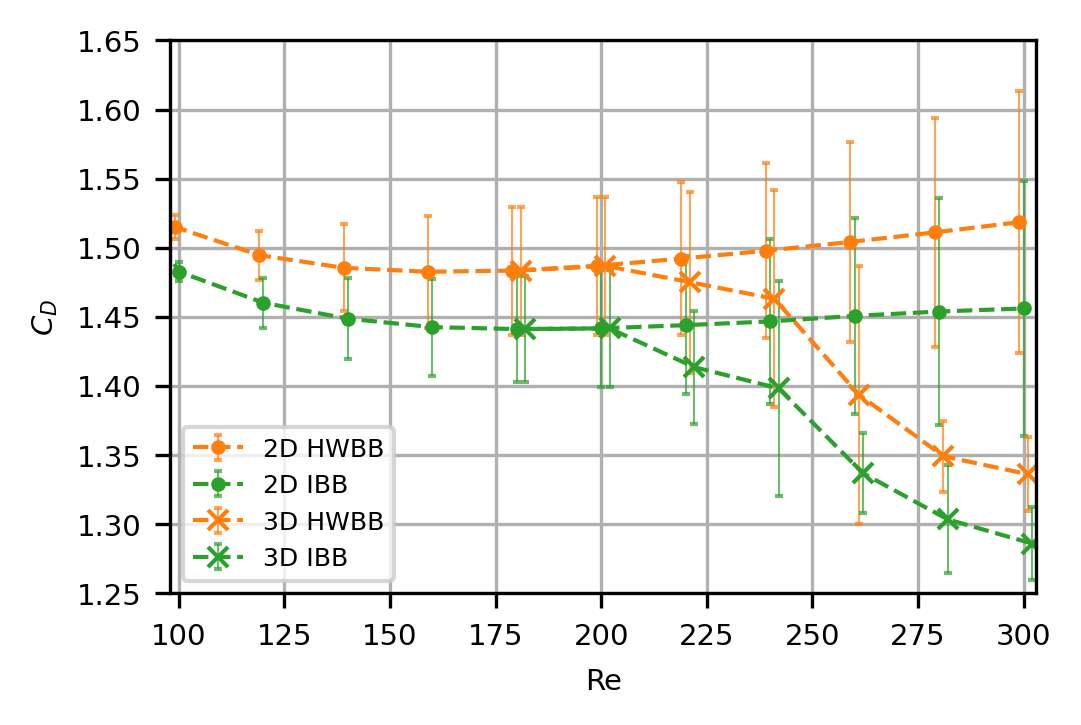

In [17]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # # Deine "converged values" (Normale Linien durch den ganzen Plot)
    # {
    #     'type': 'hline',
    #     'y': 1.38837589591116, # Hier deinen data[1,-1] Wert eintragen
    #     'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=120'}
    # },
    # {
    #     'type': 'hline',
    #     'y': 1.37895433114811, # Hier deinen data[5,-1] Wert eintragen
    #     'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=120'}
    # },
    #
    # # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    # {
    #     'type': 'ticks',
    #     'y_list': [1.4,1.31,1.19,1.31,1.33,1.172,1.29,1.45,1.26,1.36,1.4087],
    #     'label': 'literature',
    #     'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    # }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 6,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 1,           # Deine ncol=2 Anforderung aus der Legende!
    'legend_loc': 'lower left',
    'ylim': (1.25, 1.65),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'Re',
    'ylabel': r'$C_{D}$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (98,303),
    'linestyle': '--',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'Fig13a_Drag_Amplitude_New.pdf'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10,'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_amp', # Die Fehlerbalken
        'x_offset': -1.0,
        'style': {
            'label': '2D HWBB',
            'color': 'tab:orange',
            'marker': '.',
            # err bars
            'ecolor': (1.0, 0.498, 0.055, 0.7),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_amp', # Die Fehlerbalken
        'x_offset': 0,
        'style': {
            'label': '2D IBB',
            'color': 'tab:green',
            'marker': '.',
            # err bars
            'ecolor': (0.173, 0.627, 0.173, 0.7),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_amp', # Die Fehlerbalken
        'x_offset': 1,
        'style': {
            'label': '3D HWBB',
            'color': 'tab:orange',
            'marker': 'x',
            # err bars
            'ecolor': (1.0, 0.498, 0.055, 0.7),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_amp', # Die Fehlerbalken
        'x_offset': 2,
        'style': {
            'label': '3D IBB',
            'color': 'tab:green',
            'marker': 'x',
            # err bars
            'ecolor': (0.173, 0.627, 0.173, 0.7),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen)

#### Fig. 13a Drag - Errbar = stdev

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/Fig13a_Drag_stdev_New.png


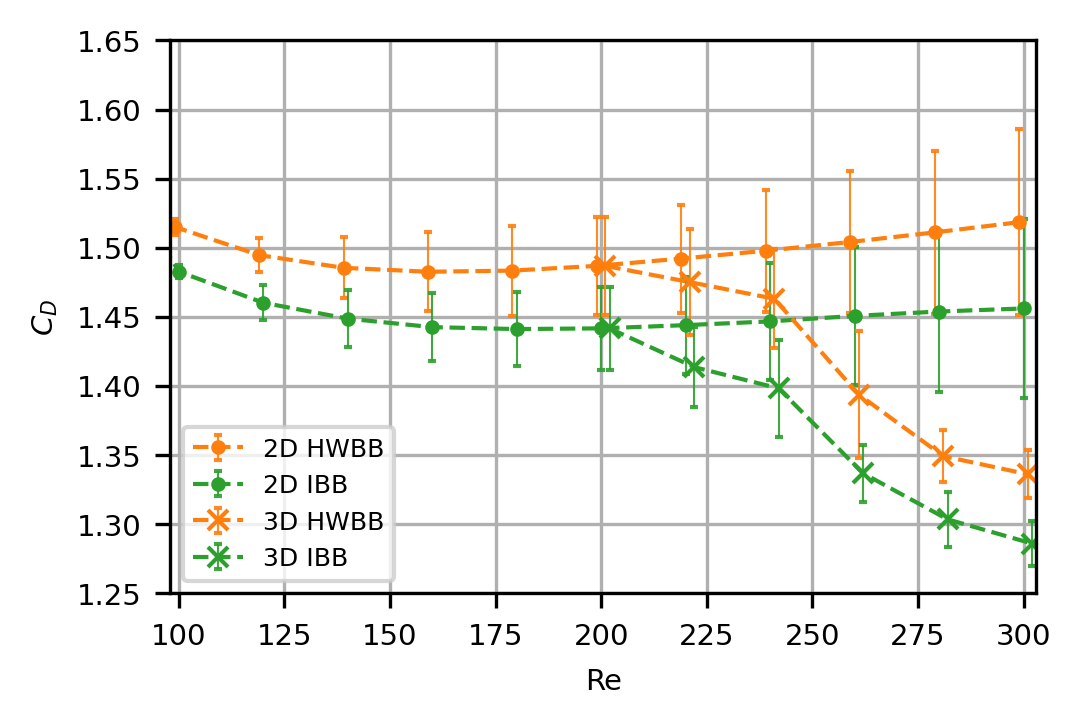

In [67]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # # Deine "converged values" (Normale Linien durch den ganzen Plot)
    # {
    #     'type': 'hline',
    #     'y': 1.38837589591116, # Hier deinen data[1,-1] Wert eintragen
    #     'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=120'}
    # },
    # {
    #     'type': 'hline',
    #     'y': 1.37895433114811, # Hier deinen data[5,-1] Wert eintragen
    #     'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=120'}
    # },
    #
    # # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    # {
    #     'type': 'ticks',
    #     'y_list': [1.4,1.31,1.19,1.31,1.33,1.172,1.29,1.45,1.26,1.36,1.4087],
    #     'label': 'literature',
    #     'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    # }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 6,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 1,           # Deine ncol=2 Anforderung aus der Legende!
    'legend_loc': 'lower left',
    'ylim': (1.25, 1.65),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'Re',
    'ylabel': r'$C_{D}$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (98,303),
    'linestyle': '--',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'Fig13a_Drag_stdev_New.png'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10,'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': -1.0,
        'style': {
            'label': '2D HWBB',
            'color': 'tab:orange',
            'marker': '.',
            # err bars
            'ecolor': (1.0, 0.498, 0.055, 0.9),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': 0,
        'style': {
            'label': '2D IBB',
            'color': 'tab:green',
            'marker': '.',
            # err bars
            'ecolor': (0.173, 0.627, 0.173, 0.9),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': 1,
        'style': {
            'label': '3D HWBB',
            'color': 'tab:orange',
            'marker': 'x',
            # err bars
            'ecolor': (1.0, 0.498, 0.055, 0.9),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': 2,
        'style': {
            'label': '3D IBB',
            'color': 'tab:green',
            'marker': 'x',
            # err bars
            'ecolor': (0.173, 0.627, 0.173, 0.9),           # Fehlerbalken sind grau (nicht blau!)
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 1,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen)

#### Fig 13a (no errbar)

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/Fig13a_Drag_noErr_New.pdf


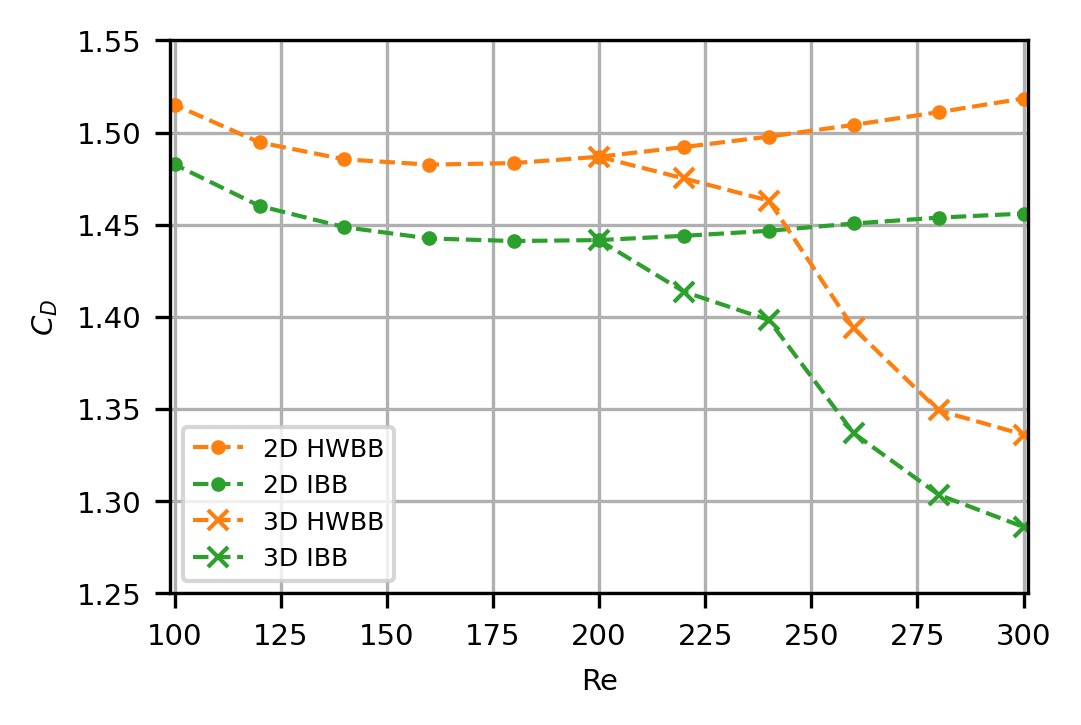

In [25]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # # Deine "converged values" (Normale Linien durch den ganzen Plot)
    # {
    #     'type': 'hline',
    #     'y': 1.38837589591116, # Hier deinen data[1,-1] Wert eintragen
    #     'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=120'}
    # },
    # {
    #     'type': 'hline',
    #     'y': 1.37895433114811, # Hier deinen data[5,-1] Wert eintragen
    #     'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=120'}
    # },
    #
    # # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    # {
    #     'type': 'ticks',
    #     'y_list': [1.4,1.31,1.19,1.31,1.33,1.172,1.29,1.45,1.26,1.36,1.4087],
    #     'label': 'literature',
    #     'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    # }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 6,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 1,           # Deine ncol=2 Anforderung aus der Legende!
    'legend_loc': 'lower left',
    'ylim': (1.25, 1.55),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'Re',
    'ylabel': r'$C_{D}$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (99,301),
    'linestyle': '--',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'Fig13a_Drag_noErr_New.pdf'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10,'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'Re',
        'y': 'Cd_mean',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
    #    'x_offset': -1.0,
        'style': {
            'label': '2D HWBB',
            'color': 'tab:orange',
            'marker': '.',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'Re',
        'y': 'Cd_mean',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 0,
        'style': {
            'label': '2D IBB',
            'color': 'tab:green',
            'marker': '.',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'Cd_mean',
    #    'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 1,
        'style': {
            'label': '3D HWBB',
            'color': 'tab:orange',
            'marker': 'x',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'Cd_mean',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 2,
        'style': {
            'label': '3D IBB',
            'color': 'tab:green',
            'marker': 'x',

            }
    },
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen)

#### FIg. 13b Cl (no err)

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/Fig13b_Lift_new.png


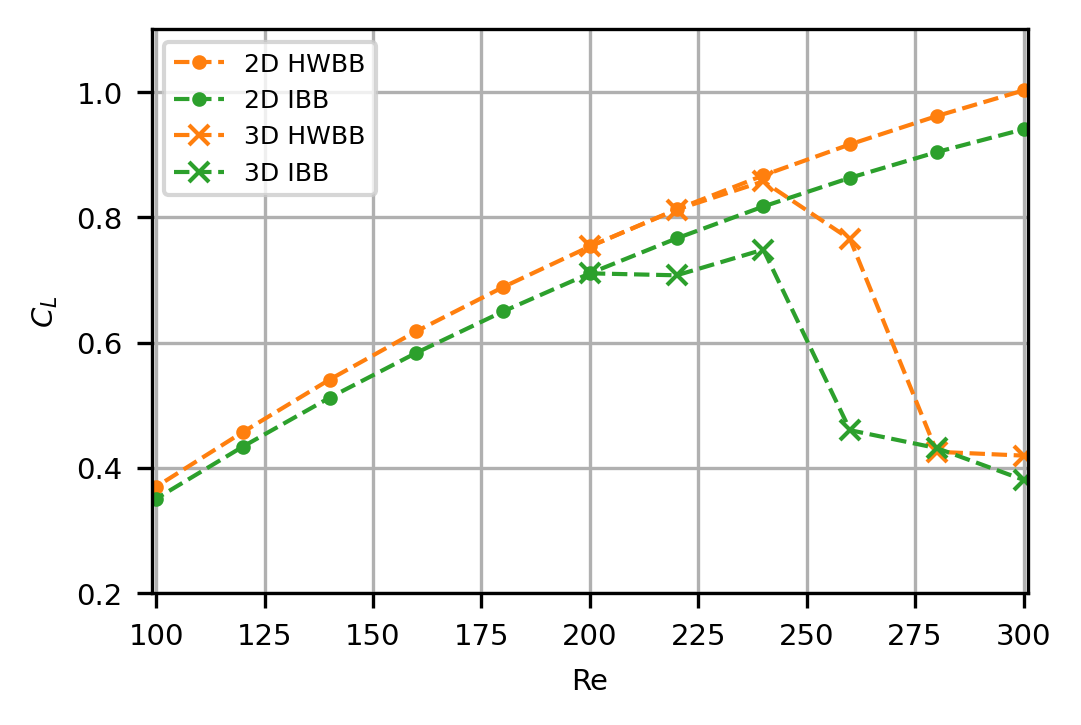

In [68]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # # Deine "converged values" (Normale Linien durch den ganzen Plot)
    # {
    #     'type': 'hline',
    #     'y': 1.38837589591116, # Hier deinen data[1,-1] Wert eintragen
    #     'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=120'}
    # },
    # {
    #     'type': 'hline',
    #     'y': 1.37895433114811, # Hier deinen data[5,-1] Wert eintragen
    #     'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=120'}
    # },
    #
    # # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    # {
    #     'type': 'ticks',
    #     'y_list': [1.4,1.31,1.19,1.31,1.33,1.172,1.29,1.45,1.26,1.36,1.4087],
    #     'label': 'literature',
    #     'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    # }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 6,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 1,           # Deine ncol=2 Anforderung aus der Legende!
    'legend_loc': 'upper left',
    'ylim': (0.2, 1.1),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'Re',
    'ylabel': r'$C_{L}$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (99,301),
    'linestyle': '--',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'Fig13b_Lift_new.png'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10,'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'Re',
        'y': 'Cl_max',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
    #    'x_offset': -1.0,
        'style': {
            'label': '2D HWBB',
            'color': 'tab:orange',
            'marker': '.',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'Re',
        'y': 'Cl_max',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 0,
        'style': {
            'label': '2D IBB',
            'color': 'tab:green',
            'marker': '.',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'Cl_max',
    #    'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 1,
        'style': {
            'label': '3D HWBB',
            'color': 'tab:orange',
            'marker': 'x',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'Cl_max',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 2,
        'style': {
            'label': '3D IBB',
            'color': 'tab:green',
            'marker': 'x',

            }
    },
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen)

#### FIg. 13c St (no err)

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/Fig13c_St_new.pdf


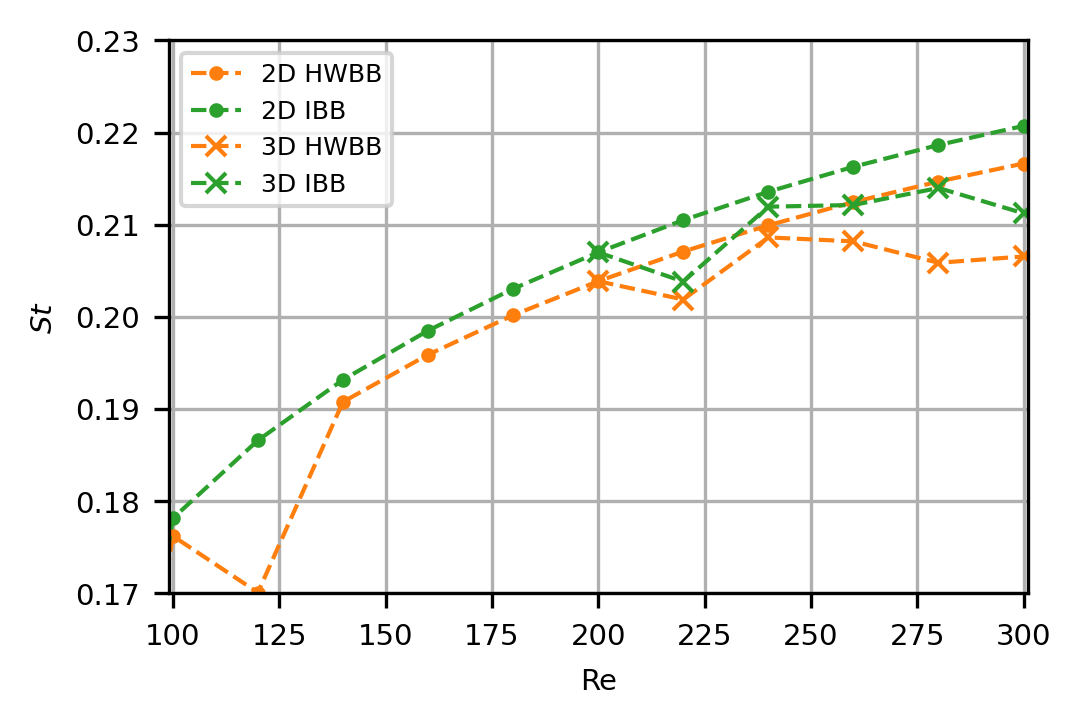

In [23]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # # Deine "converged values" (Normale Linien durch den ganzen Plot)
    # {
    #     'type': 'hline',
    #     'y': 1.38837589591116, # Hier deinen data[1,-1] Wert eintragen
    #     'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=120'}
    # },
    # {
    #     'type': 'hline',
    #     'y': 1.37895433114811, # Hier deinen data[5,-1] Wert eintragen
    #     'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=120'}
    # },
    #
    # # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    # {
    #     'type': 'ticks',
    #     'y_list': [1.4,1.31,1.19,1.31,1.33,1.172,1.29,1.45,1.26,1.36,1.4087],
    #     'label': 'literature',
    #     'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    # }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 6,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 1,           # Deine ncol=2 Anforderung aus der Legende!
    'legend_loc': 'upper left',
    'ylim': (0.17, 0.23),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'Re',
    'ylabel': r'$St$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (99,301),
    'linestyle': '--',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'Fig13c_St_new.pdf'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10,'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'Re',
        'y': 'St',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
    #    'x_offset': -1.0,
        'style': {
            'label': '2D HWBB',
            'color': 'tab:orange',
            'marker': '.',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D2Q9', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'Re',
        'y': 'St',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 0,
        'style': {
            'label': '2D IBB',
            'color': 'tab:green',
            'marker': '.',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['hwbb', 'hwbbc2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'St',
    #    'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 1,
        'style': {
            'label': '3D HWBB',
            'color': 'tab:orange',
            'marker': 'x',
            # err bars

            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10, 'GPD': 30,'collision': 'bgk', 'bc_type': ['ibb1', 'ibb1c2'], 'Re': list(np.linspace(200,300, 6, endpoint=True))},
        'x': 'Re',
        'y': 'St',
      #  'yerr': 'Cd_amp', # Die Fehlerbalken
     #   'x_offset': 2,
        'style': {
            'label': '3D IBB',
            'color': 'tab:green',
            'marker': 'x',

            }
    },
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen)

#### Fig. X for Re3900

✅ Plot gespeichert unter: /home/mbille/lettuce/mp2_paper/plots/FigX_Re3900_Errbar_test.pdf


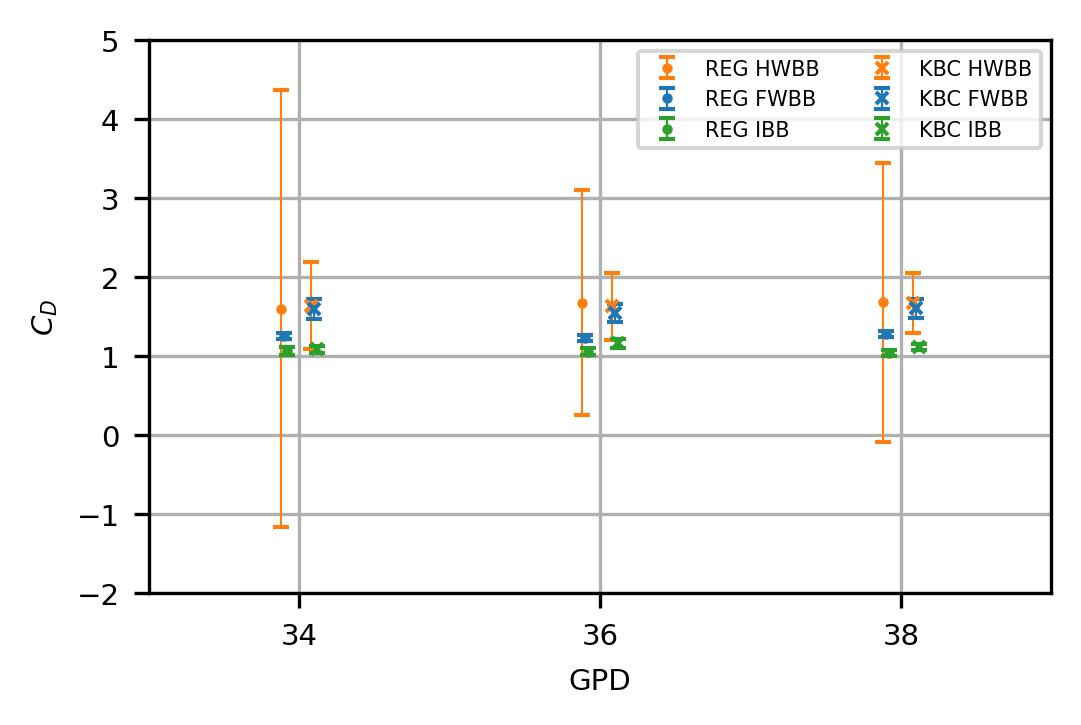

In [66]:
# 1. Die Referenzen definieren
meine_referenzen = [
    # # Deine "converged values" (Normale Linien durch den ganzen Plot)
    # {
    #     'type': 'hline',
    #     'y': 1.38837589591116, # Hier deinen data[1,-1] Wert eintragen
    #     'style': {'color': 'tab:blue', 'linestyle': ':', 'linewidth': 0.7, 'label': 'FWBB BGK GPD=120'}
    # },
    # {
    #     'type': 'hline',
    #     'y': 1.37895433114811, # Hier deinen data[5,-1] Wert eintragen
    #     'style': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 0.7, 'label': 'IBB BGK GPD=120'}
    # },
    #
    # # Deine Literatur-Werte (Nur Ticks auf der rechten Seite!)
    # {
    #     'type': 'ticks',
    #     'y_list': [1.4,1.31,1.19,1.31,1.33,1.172,1.29,1.45,1.26,1.36,1.4087],
    #     'label': 'literature',
    #     'style': {'color': 'r', 'direction': 'in', 'width': 1.2}
    # }
]

# 2. Globale Einstellungen
globale_einstellungen = {
    'fontsize': 7,
    'legend_fontsize': 5,       # Du hattest "6", kannst du hier frei wählen
    'legend_ncol': 2,           # Deine ncol=2 Anforderung aus der Legende!
  #  'legend_loc': 'lower right',
    'ylim': (-2, 5),         # Ganz wichtig: Limit setzen, damit ax1 und ax2 synchron sind
    'xlabel': 'GPD',
    'ylabel': r'$C_{D}$', # r'' erlaubt LaTeX-Formatierung
    #'xscale': 'log',                          # Für Re macht Log oft Sinn
    #'legend_loc': 'upper right',
    'xlim': (33, 39),
    'xticks': [34,36,38],
    'linestyle': '',
    'linewidth': 1,
    'markeredgewidth': 1,
    'markersize': 5,
    'figsize': (3.4876,2.301816),
    #'autolayout': True,
    'constrained_layout': True,
    'dpi': 300,
    'save_path': "/home/mbille/lettuce/mp2_paper/plots/" +'FigX_Re3900_Errbar_test.pdf'
}

# 3. Deine eigentlichen Datenkurven
meine_kurven = [
    # Hier kommen deine Simulationsreihen rein (aus der df_stats)
    # z.B.:
    # {'criteria': {'stencil': 'D2Q9', 'Ma': 0.05}, 'x': 'Re', 'y': 'Cd_mean', 'style': {'color': 'black', 'marker': 'o'}}
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10,'collision': 'reg', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': -0.12,
        'style': {
            'label': 'REG HWBB',
            'color': 'tab:orange',
            'marker': '.',
            'markersize':3,
            # err bars
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 2,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10,'collision': 'reg', 'bc_type': ['fwbb', 'fwbbc']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': -0.1,
        'style': {
            'label': 'REG FWBB',
            'color': 'tab:blue',
            'marker': '.',
            'markersize':3,
            # err bars
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 2,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10,'collision': 'reg', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': -0.08,
        'style': {
            'label': 'REG IBB',
            'color': 'tab:green',
            'marker': '.',
            'markersize':3,
            # err bars
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 2,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    # KBC
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10,'collision': 'kbc', 'bc_type': ['hwbb', 'hwbbc2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': 0.08,
        'style': {
            'label': 'KBC HWBB',
            'color': 'tab:orange',
            'marker': 'x',
            'markersize':3,
            # err bars
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 2,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10,'collision': 'kbc', 'bc_type': ['fwbb', 'fwbbc']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': +0.1,
        'style': {
            'label': 'KBC FWBB',
            'color': 'tab:blue',
            'marker': 'x',
            'markersize':3,
            # err bars
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 2,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    },
    {
        'criteria': {'stencil': 'D3Q27', 'DpY': 10,'collision': 'kbc', 'bc_type': ['ibb1', 'ibb1c2']},
        'x': 'GPD',
        'y': 'Cd_mean',
        'yerr': 'Cd_stdev', # Die Fehlerbalken
        'x_offset': +0.12,
        'style': {
            'label': 'KBC IBB',
            'color': 'tab:green',
            'marker': 'x',
            'markersize':3,
            # err bars
            'elinewidth': 0.5,          # Fehlerbalken sind dünner als die Linie
            'capsize': 2,               # Kleine Querstreifen
            'capthick': 0.7,            # Querstreifen auch dünn
            }
    }
]

# Plot starten
plot_paper_figure(df_stats, meine_kurven, globale_einstellungen)